In [1]:
# ============================
# Install Required Libraries
# ============================

!pip -q install yfinance fredapi cot_reports statsmodels arch networkx plotly matplotlib seaborn pandas numpy scipy

# ============================
# Imports
# ============================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from getpass import getpass

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

import yfinance as yf
from fredapi import Fred
from cot_reports import cot_all

from scipy import stats

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

from arch import arch_model

import networkx as nx

# ============================
# FRED API Key (Hidden Input)
# ============================

FRED_API_KEY = getpass("Enter your FRED API key: ")

# Initialize FRED client
fred = Fred(api_key=FRED_API_KEY)

# ============================
# Project Configuration
# ============================

CONFIG = {

    "START_DATE": "2018-04-03",

    "END_DATE": "2026-07-31",

    "FRED_SERIES": {
        "DGS2": "2Y Treasury",
        "DGS10": "10Y Treasury",
        "DFF": "Fed Funds Effective",
        "SOFR": "SOFR",
        "T10Y2Y": "Yield Curve 10Y-2Y",
        "T10Y3M": "Yield Curve 10Y-3M",
        "UNRATE": "Unemployment Rate",
        "CPIAUCSL": "CPI"
    },

    "YF_TICKERS": {
        "SPY": "S&P 500",
        "TLT": "20Y Treasury ETF",
        "GLD": "Gold ETF",
        "USO": "WTI Oil ETF",
        "DX-Y.NYB": "US Dollar Index"
    },

    "CBOE_URLS": {
        "VIX": "https://cdn.cboe.com/api/global/us_indices/daily_prices/VIX_History.csv",
        "VIX3M": "https://cdn.cboe.com/api/global/us_indices/daily_prices/VIX3M_History.csv",
        "VIX6M": "https://cdn.cboe.com/api/global/us_indices/daily_prices/VIX6M_History.csv"
    }

}

# ============================
# Project Directory Structure
# ============================

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Environment setup complete")
print(f"Data directory    : {DATA_DIR.resolve()}")
print(f"Outputs directory : {OUTPUT_DIR.resolve()}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 11.4 MB/s eta 0:00:00
Enter your FRED API key: ··········
✓ Environment setup complete
Data directory    : /content/data
Outputs directory : /content/outputs


In [2]:
# ============================
# Download & Process CBOE VIX Data
# ============================

vix_frames = {}

for name, url in CONFIG["CBOE_URLS"].items():

    df = pd.read_csv(url)

    df["DATE"] = pd.to_datetime(
        df["DATE"],
        format="%m/%d/%Y"
    )

    df = df[["DATE", "CLOSE"]].copy()

    df.rename(
        columns={"CLOSE": name},
        inplace=True
    )

    df = df[
        (df["DATE"] >= CONFIG["START_DATE"]) &
        (df["DATE"] <= CONFIG["END_DATE"])
    ].reset_index(drop=True)

    vix_frames[name] = df

# ============================
# Merge VIX Data
# ============================

vix_data = (
    vix_frames["VIX"]
    .merge(vix_frames["VIX3M"], on="DATE", how="outer")
    .merge(vix_frames["VIX6M"], on="DATE", how="outer")
    .sort_values("DATE")
    .reset_index(drop=True)
)

# ============================
# Derived Features
# ============================

vix_data["VIX_term_slope"] = (
    (vix_data["VIX3M"] - vix_data["VIX"]) /
    vix_data["VIX"]
)

vix_data["VIX_contango_flag"] = (
    vix_data["VIX_term_slope"] > 0.05
).astype(int)

# ============================
# Save
# ============================

output_path = DATA_DIR / "vix_data.csv"

vix_data.to_csv(
    output_path,
    index=False
)

# ============================
# Summary
# ============================

print("=" * 60)
print("VIX DATASET CREATED")
print("=" * 60)

print(f"\nShape: {vix_data.shape}")

print("\nHead (3 rows):")
print(vix_data.head(3))

print("\nTail (3 rows):")
print(vix_data.tail(3))

VIX DATASET CREATED

Shape: (2126, 6)

Head (3 rows):
        DATE    VIX  VIX3M  VIX6M  VIX_term_slope  VIX_contango_flag
0 2018-04-03  21.10  21.02  21.26       -0.003791                  0
1 2018-04-04  20.06  20.42  20.85        0.017946                  0
2 2018-04-05  18.94  19.61  20.13        0.035375                  0

Tail (3 rows):
           DATE    VIX  VIX3M  VIX6M  VIX_term_slope  VIX_contango_flag
2123 2026-07-29  20.66  21.50  23.06        0.040658                  0
2124 2026-07-30  17.09  19.50  21.61        0.141018                  1
2125 2026-07-31  15.99  19.02  21.34        0.189493                  1


In [3]:
# ============================
# Download FRED Data
# ============================

from fredapi import Fred

fred = Fred(api_key=FRED_API_KEY)

fred_frames = {}

for series_id in CONFIG["FRED_SERIES"]:

    series = fred.get_series(
        series_id,
        observation_start=CONFIG["START_DATE"],
        observation_end=CONFIG["END_DATE"]
    )

    df = (
        series
        .rename(series_id)
        .to_frame()
        .reset_index()
    )

    df.columns = ["DATE", series_id]

    df["DATE"] = pd.to_datetime(df["DATE"])

    fred_frames[series_id] = df

# ============================
# Merge All Series
# ============================

fred_data = None

for series_id in CONFIG["FRED_SERIES"]:

    if fred_data is None:
        fred_data = fred_frames[series_id]
    else:
        fred_data = fred_data.merge(
            fred_frames[series_id],
            on="DATE",
            how="outer"
        )

fred_data = (
    fred_data
    .sort_values("DATE")
    .reset_index(drop=True)
)

# ============================
# Handle Missing Values
# ============================

treasury_cols = ["DGS2", "DGS10"]

fred_data[treasury_cols] = fred_data[treasury_cols].ffill()

# CPIAUCSL and UNRATE intentionally left unchanged
# (monthly series will be forward-filled later)

# ============================
# Save
# ============================

output_path = DATA_DIR / "fred_data.csv"

fred_data.to_csv(
    output_path,
    index=False
)

# ============================
# Summary
# ============================

print("=" * 60)
print("FRED DATASET CREATED")
print("=" * 60)

print(f"\nShape: {fred_data.shape}")

print("\nColumns:")
print(list(fred_data.columns))

print("\nNon-null values per column:")
print(fred_data.count())

FRED DATASET CREATED

Shape: (3043, 9)

Columns:
['DATE', 'DGS2', 'DGS10', 'DFF', 'SOFR', 'T10Y2Y', 'T10Y3M', 'UNRATE', 'CPIAUCSL']

Non-null values per column:
DATE        3043
DGS2        3042
DGS10       3042
DFF         3041
SOFR        2079
T10Y2Y      2083
T10Y3M      2083
UNRATE        98
CPIAUCSL      98
dtype: int64


In [4]:
# ============================
# Download Yahoo Finance Data
# ============================

import yfinance as yf

fallback_used = []

try:

    yf_data = yf.download(
        tickers=list(CONFIG["YF_TICKERS"].keys()),
        start=CONFIG["START_DATE"],
        end=CONFIG["END_DATE"],
        auto_adjust=True,
        progress=False
    )

    # ----------------------------
    # Extract Adjusted Close Prices
    # ----------------------------

    if isinstance(yf_data.columns, pd.MultiIndex):

        if "Close" in yf_data.columns.get_level_values(0):
            yf_data = yf_data["Close"]

        elif "Adj Close" in yf_data.columns.get_level_values(0):
            yf_data = yf_data["Adj Close"]

        else:
            raise ValueError("Neither 'Close' nor 'Adj Close' found.")

    yf_data = yf_data.reset_index()

    # ----------------------------
    # Rename Columns
    # ----------------------------

    rename_map = {
        ticker: CONFIG["YF_TICKERS"][ticker]
        for ticker in CONFIG["YF_TICKERS"]
        if ticker in yf_data.columns
    }

    yf_data.rename(columns=rename_map, inplace=True)

except Exception as e:

    print(f"Yahoo Finance download failed.\nReason: {e}")

    dates = pd.date_range(
        CONFIG["START_DATE"],
        CONFIG["END_DATE"],
        freq="D"
    )

    yf_data = pd.DataFrame({"Date": dates})

# ============================
# Individual Fallback Checks
# ============================

fallback_map = {
    "US Dollar Index": "DTWEXBGS",
    "WTI Oil ETF": "DCOILWTICO",
    "Gold ETF": "GOLDAMGBD228NLBM",
    "S&P 500": "SP500"
}

for asset_name, fred_series in fallback_map.items():

    if asset_name not in yf_data.columns or yf_data[asset_name].isna().all():

        print(f"yfinance failed for {asset_name}, using FRED fallback")

        fallback_used.append(asset_name)

        series = fred.get_series(
            fred_series,
            observation_start=CONFIG["START_DATE"],
            observation_end=CONFIG["END_DATE"]
        )

        temp = (
            series
            .rename(asset_name)
            .to_frame()
            .reset_index()
        )

        temp.columns = ["Date", asset_name]

        yf_data = yf_data.merge(
            temp,
            on="Date",
            how="left",
            suffixes=("", "_fred")
        )

        if asset_name + "_fred" in yf_data.columns:
            yf_data[asset_name] = yf_data[asset_name].combine_first(
                yf_data[asset_name + "_fred"]
            )
            yf_data.drop(columns=[asset_name + "_fred"], inplace=True)

# ============================
# Final Formatting
# ============================

yf_data.rename(columns={"Date": "DATE"}, inplace=True)

yf_data.sort_values("DATE", inplace=True)

# ============================
# Save
# ============================

output_path = DATA_DIR / "yf_data.csv"

yf_data.to_csv(
    output_path,
    index=False
)

# ============================
# Summary
# ============================

print("=" * 60)
print("YAHOO FINANCE DATASET CREATED")
print("=" * 60)

print(f"\nShape: {yf_data.shape}")

print("\nHead (3 rows):")
print(yf_data.head(3))

print("\nFallback tickers used:")

if fallback_used:
    print(fallback_used)
else:
    print("None")

YAHOO FINANCE DATASET CREATED

Shape: (2095, 6)

Head (3 rows):
Ticker       DATE  US Dollar Index    Gold ETF     S&P 500  20Y Treasury ETF  \
0      2018-04-03        90.199997  126.300003  229.847961         95.369041   
1      2018-04-04        90.139999  126.449997  232.307114         95.171898   
2      2018-04-05        90.459999  125.800003  234.140472         94.462242   

Ticker  WTI Oil ETF  
0        102.480003  
1        102.559998  
2        102.639999  

Fallback tickers used:
None


In [7]:
# ============================
# Download CFTC TFF COT Data
# ============================

from cot_reports import cot_all

cot_df = cot_all(
    cot_report_type="traders_in_financial_futures_fut"
)

# ============================
# Filter Required Markets
# ============================

markets = [
    "E-MINI S&P 500",
    "10-YEAR U.S. TREASURY NOTES",
    "2-YEAR U.S. TREASURY NOTES"
]

pattern = "|".join(markets)

cot_data = cot_df[
    cot_df["Market_and_Exchange_Names"]
    .str.contains(pattern, case=False, na=False)
].copy()

# ============================
# Keep Required Columns
# (Mapped to current TFF schema)
# ============================

cot_data = cot_data[
    [
        "Market_and_Exchange_Names",
        "Report_Date_as_YYYY-MM-DD",
        "Open_Interest_All",
        "Lev_Money_Positions_Long_All",
        "Lev_Money_Positions_Short_All",
        "Dealer_Positions_Long_All",
        "Dealer_Positions_Short_All",
    ]
].copy()

# Rename so the rest of the analysis follows
# the requested prompt terminology.

cot_data.rename(
    columns={
        "Report_Date_as_YYYY-MM-DD": "Report_Date_as_YYYY_MM_DD",
        "Lev_Money_Positions_Long_All": "NonComm_Positions_Long_All",
        "Lev_Money_Positions_Short_All": "NonComm_Positions_Short_All",
        "Dealer_Positions_Long_All": "Comm_Positions_Long_All",
        "Dealer_Positions_Short_All": "Comm_Positions_Short_All",
    },
    inplace=True,
)

# ============================
# Convert Date
# ============================

cot_data["Report_Date_as_YYYY_MM_DD"] = pd.to_datetime(
    cot_data["Report_Date_as_YYYY_MM_DD"]
)

# ============================
# Restrict Date Range
# ============================

cot_data = cot_data[
    (
        cot_data["Report_Date_as_YYYY_MM_DD"]
        >= CONFIG["START_DATE"]
    )
    &
    (
        cot_data["Report_Date_as_YYYY_MM_DD"]
        <= CONFIG["END_DATE"]
    )
].reset_index(drop=True)

# ============================
# Derived Metrics
# ============================

cot_data["noncomm_net"] = (
    cot_data["NonComm_Positions_Long_All"]
    -
    cot_data["NonComm_Positions_Short_All"]
)

cot_data["comm_net"] = (
    cot_data["Comm_Positions_Long_All"]
    -
    cot_data["Comm_Positions_Short_All"]
)

cot_data["noncomm_pct_oi"] = (
    cot_data["noncomm_net"]
    /
    cot_data["Open_Interest_All"]
)

# ============================
# Save
# ============================

output_path = DATA_DIR / "cot_data.csv"

cot_data.to_csv(
    output_path,
    index=False
)

# ============================
# Summary
# ============================

print("=" * 60)
print("COT DATASET CREATED")
print("=" * 60)

print(f"\nShape: {cot_data.shape}")

print("\nSample noncomm_pct_oi by market:")

for market in markets:

    sample = (
        cot_data[
            cot_data["Market_and_Exchange_Names"]
            .str.contains(market, case=False, na=False)
        ][
            [
                "Report_Date_as_YYYY_MM_DD",
                "noncomm_pct_oi",
            ]
        ]
        .head(5)
    )

    print(f"\n{market}")
    print(sample)

Selected: COT Traders in Financial Futures report. Futures only.
Stored the extracted file F_TFF_2006_2016.txt in the working directory.
Selected: traders_in_financial_futures_fut
Downloaded single year data from: 2017
Stored the file FinFutYY.txt in the working directory.
Selected: traders_in_financial_futures_fut
Downloaded single year data from: 2018
Stored the file FinFutYY.txt in the working directory.
Selected: traders_in_financial_futures_fut
Downloaded single year data from: 2019
Stored the file FinFutYY.txt in the working directory.
Selected: traders_in_financial_futures_fut
Downloaded single year data from: 2020
Stored the file FinFutYY.txt in the working directory.
Selected: traders_in_financial_futures_fut
Downloaded single year data from: 2021
Stored the file FinFutYY.txt in the working directory.
Selected: traders_in_financial_futures_fut
Downloaded single year data from: 2022
Stored the file FinFutYY.txt in the working directory.
Selected: traders_in_financial_futures_fu

In [8]:
# ============================
# FOMC / CPI / NFP Event Calendar
# ============================

from datetime import datetime
import calendar

# ============================
# FOMC Dates
# ============================

FOMC_DATES = {

    2018: [
        "01/31/2018","03/21/2018","05/02/2018","06/13/2018",
        "08/01/2018","09/26/2018","11/08/2018","12/19/2018"
    ],

    2019: [
        "01/30/2019","03/20/2019","05/01/2019","06/19/2019",
        "07/31/2019","09/18/2019","10/30/2019","12/11/2019"
    ],

    2020: [
        "01/29/2020","03/15/2020","04/29/2020","06/10/2020",
        "07/29/2020","09/16/2020","11/05/2020","12/16/2020"
    ],

    2021: [
        "01/27/2021","03/17/2021","04/28/2021","06/16/2021",
        "07/28/2021","09/22/2021","11/03/2021","12/15/2021"
    ],

    2022: [
        "01/26/2022","03/16/2022","05/04/2022","06/15/2022",
        "07/27/2022","09/21/2022","11/02/2022","12/14/2022"
    ],

    2023: [
        "02/01/2023","03/22/2023","05/03/2023","06/14/2023",
        "07/26/2023","09/20/2023","11/01/2023","12/13/2023"
    ],

    2024: [
        "01/31/2024","03/20/2024","05/01/2024","06/12/2024",
        "07/31/2024","09/18/2024","11/07/2024","12/18/2024"
    ],

    2025: [
        "01/29/2025","03/19/2025","05/07/2025","06/18/2025",
        "07/30/2025","09/17/2025","11/07/2025","12/17/2025"
    ],

    2026: [
        "01/28/2026","03/18/2026","04/29/2026","06/17/2026",
        "07/29/2026","09/16/2026","10/28/2026","12/09/2026"
    ]

}

# ============================
# FOMC DataFrame
# ============================

fomc_rows = []

for year, dates in FOMC_DATES.items():

    for d in dates:

        fomc_rows.append({
            "DATE": pd.to_datetime(d, format="%m/%d/%Y"),
            "EVENT_TYPE": "FOMC"
        })

fomc_df = pd.DataFrame(fomc_rows)

# ============================
# CPI Dates (15th of each month)
# ============================

cpi_rows = []

for year in range(2018, 2027):

    start_month = 4 if year == 2018 else 1
    end_month = 7 if year == 2026 else 12

    for month in range(start_month, end_month + 1):

        cpi_rows.append({
            "DATE": pd.Timestamp(year, month, 15),
            "EVENT_TYPE": "CPI"
        })

cpi_df = pd.DataFrame(cpi_rows)

# ============================
# NFP Dates (First Friday)
# ============================

nfp_rows = []

for year in range(2018, 2027):

    start_month = 4 if year == 2018 else 1
    end_month = 7 if year == 2026 else 12

    for month in range(start_month, end_month + 1):

        cal = calendar.monthcalendar(year, month)

        if cal[0][calendar.FRIDAY] != 0:
            day = cal[0][calendar.FRIDAY]
        else:
            day = cal[1][calendar.FRIDAY]

        nfp_rows.append({
            "DATE": pd.Timestamp(year, month, day),
            "EVENT_TYPE": "NFP"
        })

nfp_df = pd.DataFrame(nfp_rows)

# ============================
# Combine Event Calendar
# ============================

events_data = pd.concat(
    [fomc_df, cpi_df, nfp_df],
    ignore_index=True
)

events_data = (
    events_data
    .sort_values("DATE")
    .reset_index(drop=True)
)

# ============================
# Save
# ============================

output_path = DATA_DIR / "events_data.csv"

events_data.to_csv(
    output_path,
    index=False
)

# ============================
# Summary
# ============================

print("=" * 60)
print("EVENT CALENDAR CREATED")
print("=" * 60)

print("\nEvent Counts:\n")
print(events_data["EVENT_TYPE"].value_counts())

EVENT CALENDAR CREATED

Event Counts:

EVENT_TYPE
NFP     100
CPI     100
FOMC     72
Name: count, dtype: int64


In [10]:
# ============================
# Load Saved Datasets
# ============================

vix_data = pd.read_csv(
    DATA_DIR / "vix_data.csv",
    parse_dates=["DATE"]
)

fred_data = pd.read_csv(
    DATA_DIR / "fred_data.csv",
    parse_dates=["DATE"]
)

yf_data = pd.read_csv(
    DATA_DIR / "yf_data.csv",
    parse_dates=["DATE"]
)

events_data = pd.read_csv(
    DATA_DIR / "events_data.csv",
    parse_dates=["DATE"]
)

# ============================
# Standardize Yahoo Finance Names
# ============================

rename_map = {
    "S&P 500": "SPY",
    "20Y Treasury ETF": "TLT",
    "Gold ETF": "GLD",
    "WTI Oil ETF": "USO",
    "US Dollar Index": "DXY"
}

yf_data.rename(columns=rename_map, inplace=True)

# Remove accidental MultiIndex name
yf_data.columns.name = None

# ============================
# Merge All Datasets
# ============================

master = (
    vix_data
    .merge(fred_data, on="DATE", how="outer")
    .merge(yf_data, on="DATE", how="outer")
    .merge(events_data, on="DATE", how="left")
)

master = (
    master
    .sort_values("DATE")
    .set_index("DATE")
)

master["EVENT_TYPE"] = master["EVENT_TYPE"].astype("category")

# ============================
# Handle Missing Values
# ============================

treasury_cols = [
    "DGS2",
    "DGS10",
    "T10Y2Y",
    "T10Y3M"
]

master[treasury_cols] = master[treasury_cols].ffill()

master["UNRATE"] = master["UNRATE"].ffill()

master["CPIAUCSL"] = master["CPIAUCSL"].ffill()

# ============================
# Derived Variables
# ============================

master["spy_ret"] = master["SPY"].pct_change()

master["tlt_ret"] = master["TLT"].pct_change()

master["gld_ret"] = master["GLD"].pct_change()

master["uso_ret"] = master["USO"].pct_change()

master["dxy_ret"] = master["DXY"].pct_change()

master["dgs2_change"] = master["DGS2"].diff()

master["dgs10_change"] = master["DGS10"].diff()

master["curve_change"] = master["T10Y2Y"].diff()

master["sofr_effr_spread"] = (
    master["SOFR"] - master["DFF"]
)

# ============================
# Remove Initial Missing Returns
# ============================

required = [
    "spy_ret",
    "tlt_ret",
    "gld_ret",
    "uso_ret",
    "dxy_ret",
    "dgs2_change",
    "dgs10_change"
]

master = master.dropna(subset=required)

# ============================
# Volatility Regime
# ============================

master["regime"] = "normal_vol"

master.loc[
    master["VIX"] < 15,
    "regime"
] = "low_vol"

master.loc[
    master["VIX"] > 25,
    "regime"
] = "high_vol"

master["regime"] = pd.Categorical(
    master["regime"],
    categories=[
        "low_vol",
        "normal_vol",
        "high_vol"
    ],
    ordered=True
)

# ============================
# Save
# ============================

master.to_csv(DATA_DIR / "master_data.csv")

# ============================
# Summary
# ============================

print("=" * 60)
print("MASTER DATASET CREATED")
print("=" * 60)

print("\nShape:")
print(master.shape)

print("\nColumns:")
print(master.columns.tolist())

print("\nRegime Distribution:")
print(master["regime"].value_counts())

MASTER DATASET CREATED

Shape:
(3045, 29)

Columns:
['VIX', 'VIX3M', 'VIX6M', 'VIX_term_slope', 'VIX_contango_flag', 'DGS2', 'DGS10', 'DFF', 'SOFR', 'T10Y2Y', 'T10Y3M', 'UNRATE', 'CPIAUCSL', 'DXY', 'GLD', 'SPY', 'TLT', 'USO', 'EVENT_TYPE', 'spy_ret', 'tlt_ret', 'gld_ret', 'uso_ret', 'dxy_ret', 'dgs2_change', 'dgs10_change', 'curve_change', 'sofr_effr_spread', 'regime']

Regime Distribution:
regime
normal_vol    2159
low_vol        524
high_vol       362
Name: count, dtype: int64


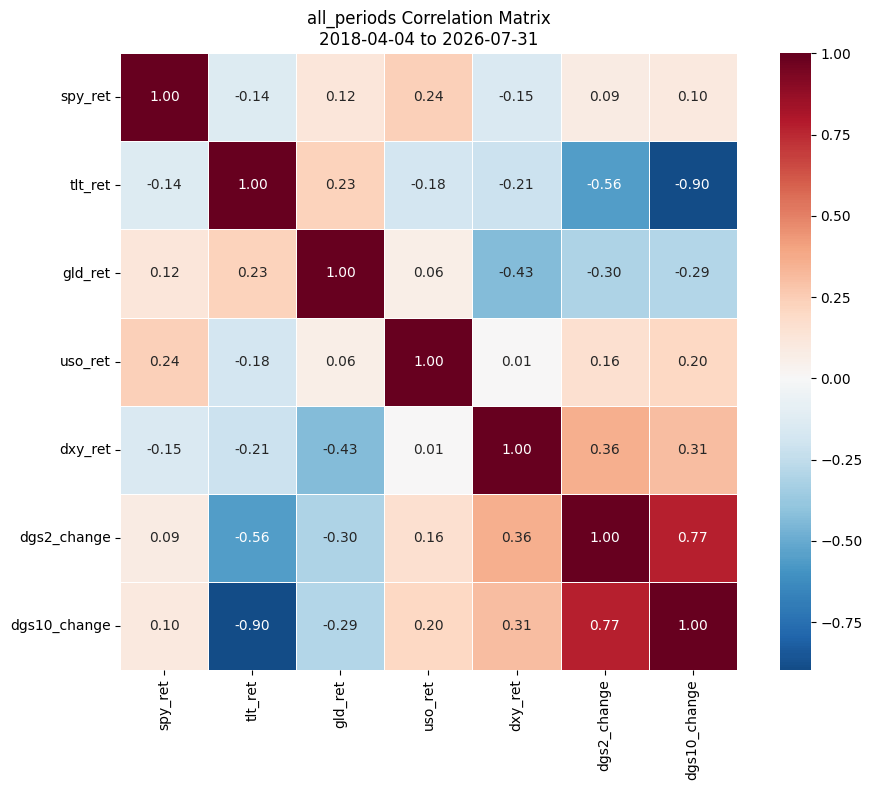

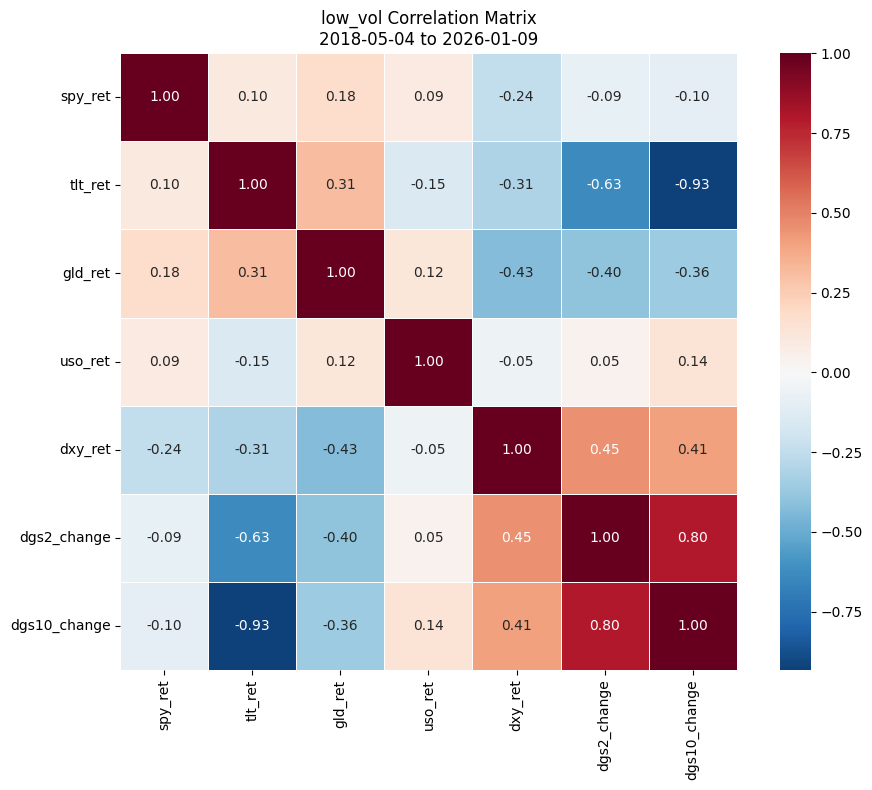

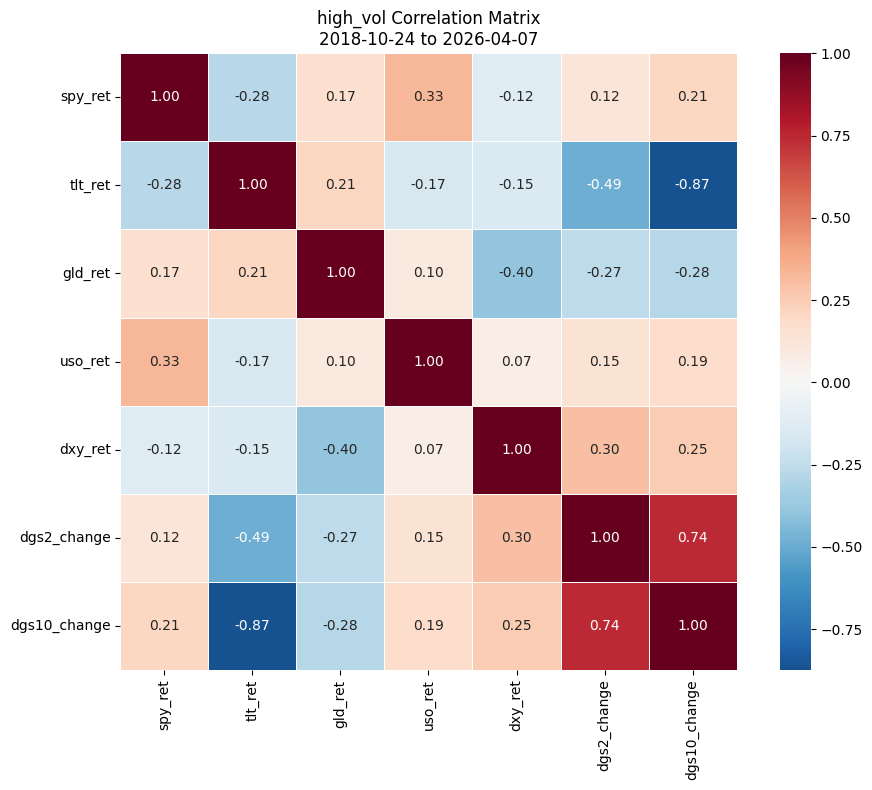

Average SPY vs TLT Correlation
low_vol     : 0.0975
normal_vol  : -0.0325
high_vol    : -0.2788


In [11]:
# ============================
# Rolling Correlation Analysis
# ============================

import os

master = pd.read_csv(
    DATA_DIR / "master_data.csv",
    parse_dates=["DATE"],
    index_col="DATE"
)

returns = [
    "spy_ret",
    "tlt_ret",
    "gld_ret",
    "uso_ret",
    "dxy_ret",
    "dgs2_change",
    "dgs10_change"
]

# ============================
# Rolling Correlations
# ============================

rolling_corr_30 = (
    master[returns]
    .rolling(window=30)
    .corr()
)

rolling_corr_90 = (
    master[returns]
    .rolling(window=90)
    .corr()
)

# ============================
# Heatmap Function
# ============================

def save_heatmap(df, regime_name):

    corr = df[returns].corr(method="pearson")

    plt.figure(figsize=(10,8))

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        square=True,
        linewidths=0.5
    )

    if len(df) > 0:
        start = df.index.min().date()
        end = df.index.max().date()
        title = f"{regime_name} Correlation Matrix\n{start} to {end}"
    else:
        title = f"{regime_name} Correlation Matrix"

    plt.title(title)

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / f"correlation_heatmap_{regime_name}.png",
        dpi=300
    )

    plt.show()

# ============================
# Heatmaps
# ============================

save_heatmap(
    master,
    "all_periods"
)

save_heatmap(
    master[master["regime"] == "low_vol"],
    "low_vol"
)

save_heatmap(
    master[master["regime"] == "high_vol"],
    "high_vol"
)

# ============================
# Flight-to-Quality Metric
# ============================

print("=" * 60)
print("Average SPY vs TLT Correlation")
print("=" * 60)

for regime in ["low_vol", "normal_vol", "high_vol"]:

    df = master[
        master["regime"] == regime
    ]

    corr = df["spy_ret"].corr(df["tlt_ret"])

    print(f"{regime:12s}: {corr:.4f}")

In [13]:
# ============================
# Vector Autoregression (VAR)
# ============================

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller

# ============================
# Load Master Dataset
# ============================

master = pd.read_csv(
    DATA_DIR / "master_data.csv",
    parse_dates=["DATE"],
    index_col="DATE"
)

# ============================
# Endogenous Variables
# ============================

endog = [
    "spy_ret",
    "tlt_ret",
    "gld_ret",
    "dgs2_change",
    "dgs10_change",
    "dxy_ret"
]

endog_data = master[endog].copy()

endog_data = endog_data.dropna()

# ============================
# Stationarity Test
# ============================

print("=" * 60)
print("ADF STATIONARITY TEST")
print("=" * 60)

for col in endog:

    adf = adfuller(
        endog_data[col],
        maxlag=5,
        regression="c",
        autolag="AIC"
    )

    p_value = adf[1]

    print(f"{col:15s}  p-value = {p_value:.6f}")

    if p_value > 0.05:

        print(f"WARNING: {col} is non-stationary. Applying first difference.")

        endog_data[col] = endog_data[col].diff()

# Remove rows introduced by differencing
endog_data = endog_data.dropna()

# ============================
# Lag Order Selection
# ============================

print("\n" + "=" * 60)
print("VAR LAG ORDER SELECTION")
print("=" * 60)

model = VAR(endog_data)

lag_results = model.select_order(maxlags=10)

print(lag_results.summary())

# Choose lag using AIC
lag_order = lag_results.aic

# Safety fallback
if lag_order is None:
    lag_order = 2

lag_order = int(lag_order)

print(f"\nSelected Lag (AIC): {lag_order}")

# ============================
# Fit VAR Model
# ============================

print("\n" + "=" * 60)
print("FITTING VAR MODEL")
print("=" * 60)

fitted = model.fit(lag_order)

summary = fitted.summary()

# Display in notebook
print(summary)

# ============================
# Save Summary
# ============================

output_path = OUTPUT_DIR / "var_summary.txt"

with open(output_path, "w", encoding="utf-8") as f:
    f.write(str(summary))

print("\nSaved VAR summary to:")
print(output_path.resolve())

ADF STATIONARITY TEST
spy_ret          p-value = 0.000000
tlt_ret          p-value = 0.000000
gld_ret          p-value = 0.000000
dgs2_change      p-value = 0.000000
dgs10_change     p-value = 0.000000
dxy_ret          p-value = 0.000000

VAR LAG ORDER SELECTION


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -55.09      -55.08   1.184e-24      -55.09
1       -55.17     -55.09*   1.095e-24     -55.14*
2       -55.18      -55.03   1.080e-24      -55.13
3       -55.19      -54.96   1.077e-24      -55.11
4       -55.19      -54.89   1.079e-24      -55.08
5       -55.18      -54.81   1.083e-24      -55.05
6      -55.19*      -54.75  1.074e-24*      -55.03
7       -55.19      -54.68   1.075e-24      -55.01
8       -55.18      -54.60   1.080e-24      -54.98
9       -55.18      -54.53   1.083e-24      -54.95
10      -55.18      -54.46   1.084e-24      -54.92
--------------------------------------------------

Selected Lag (AIC): 6

FITTING VAR MODEL
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 02, Aug, 2026
Time:                     13:55:27
------------------

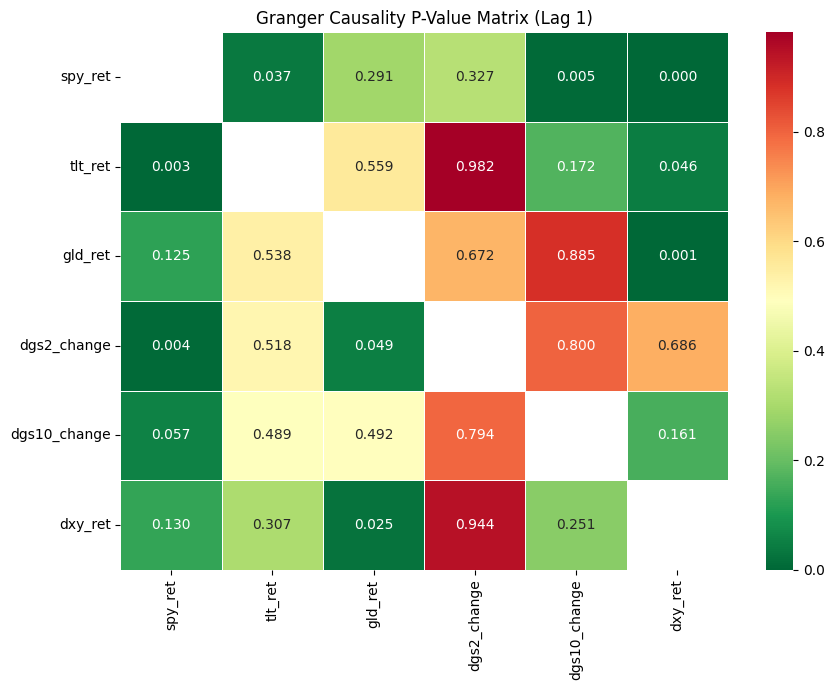

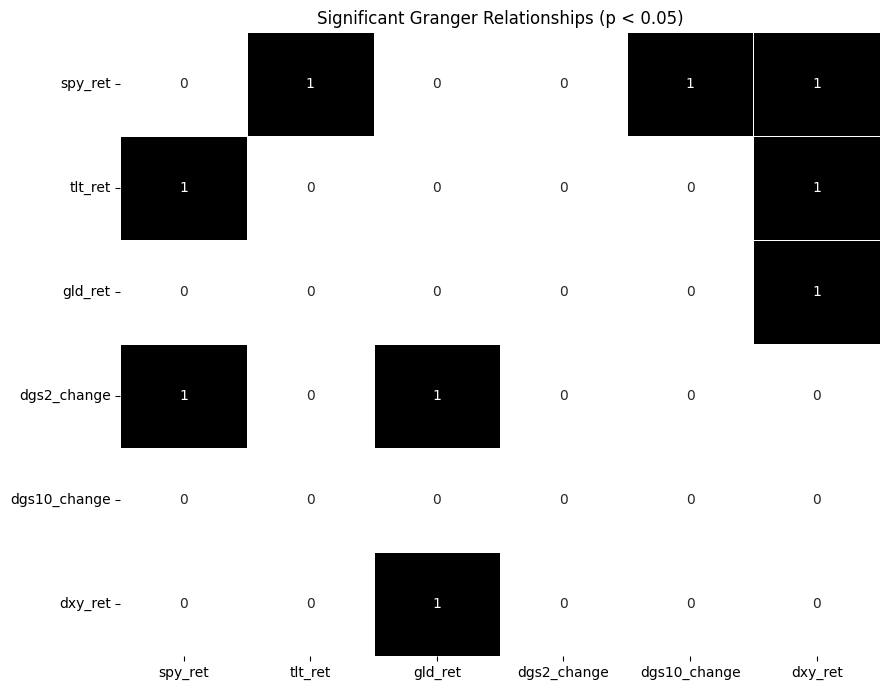

TOP 5 MOST SIGNIFICANT GRANGER RELATIONSHIPS
         Cause        Effect       P_Value
0      spy_ret       dxy_ret  5.414760e-15
1      gld_ret       dxy_ret  7.062614e-04
2      tlt_ret       spy_ret  2.732066e-03
3  dgs2_change       spy_ret  3.994780e-03
4      spy_ret  dgs10_change  5.063336e-03


In [14]:
# ============================
# Pairwise Granger Causality
# ============================

from statsmodels.tsa.stattools import grangercausalitytests

# ============================
# Load Master Dataset
# ============================

master = pd.read_csv(
    DATA_DIR / "master_data.csv",
    parse_dates=["DATE"],
    index_col="DATE"
)

# ============================
# Endogenous Variables
# ============================

endog = [
    "spy_ret",
    "tlt_ret",
    "gld_ret",
    "dgs2_change",
    "dgs10_change",
    "dxy_ret"
]

data = master[endog].dropna()

# ============================
# Initialize Matrices
# ============================

pvalue_matrix = pd.DataFrame(
    np.nan,
    index=endog,
    columns=endog
)

binary_matrix = pd.DataFrame(
    np.nan,
    index=endog,
    columns=endog
)

results_list = []

# ============================
# Pairwise Granger Tests
# ============================

for cause in endog:

    for effect in endog:

        if cause == effect:
            continue

        try:

            test_data = data[[effect, cause]]

            result = grangercausalitytests(
                test_data,
                maxlag=5,
                verbose=False
            )

            p_value = result[1][0]["ssr_ftest"][1]

        except Exception:

            p_value = np.nan

        pvalue_matrix.loc[cause, effect] = p_value

        if pd.notna(p_value):
            binary_matrix.loc[cause, effect] = int(p_value < 0.05)

            results_list.append({
                "Cause": cause,
                "Effect": effect,
                "P_Value": p_value
            })

# ============================
# Binary Matrix Formatting
# ============================

binary_plot = binary_matrix.fillna(0).astype(int)

# ============================
# P-Value Heatmap
# ============================

plt.figure(figsize=(9,7))

sns.heatmap(
    pvalue_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
    linewidths=0.5
)

plt.title("Granger Causality P-Value Matrix (Lag 1)")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "granger_pvalue_matrix.png",
    dpi=300
)

plt.show()

# ============================
# Binary Heatmap
# ============================

plt.figure(figsize=(9,7))

sns.heatmap(
    binary_plot,
    annot=True,
    fmt="d",
    cmap="binary",
    linewidths=0.5,
    cbar=False
)

plt.title("Significant Granger Relationships (p < 0.05)")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "granger_binary_matrix.png",
    dpi=300
)

plt.show()

# ============================
# Top Relationships
# ============================

results_df = (
    pd.DataFrame(results_list)
    .sort_values("P_Value")
    .reset_index(drop=True)
)

print("=" * 60)
print("TOP 5 MOST SIGNIFICANT GRANGER RELATIONSHIPS")
print("=" * 60)

print(results_df.head(5))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


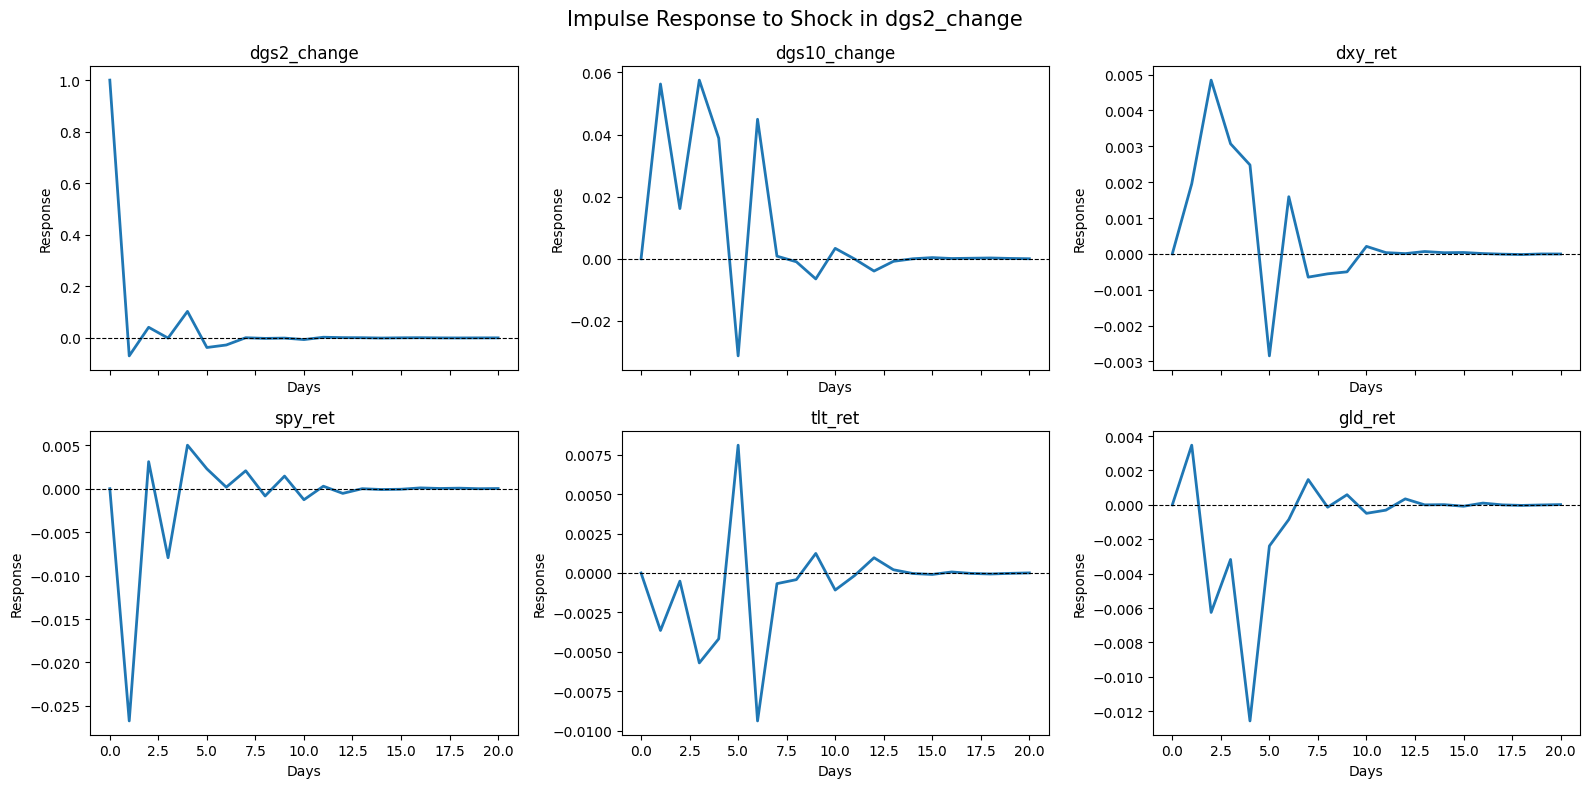

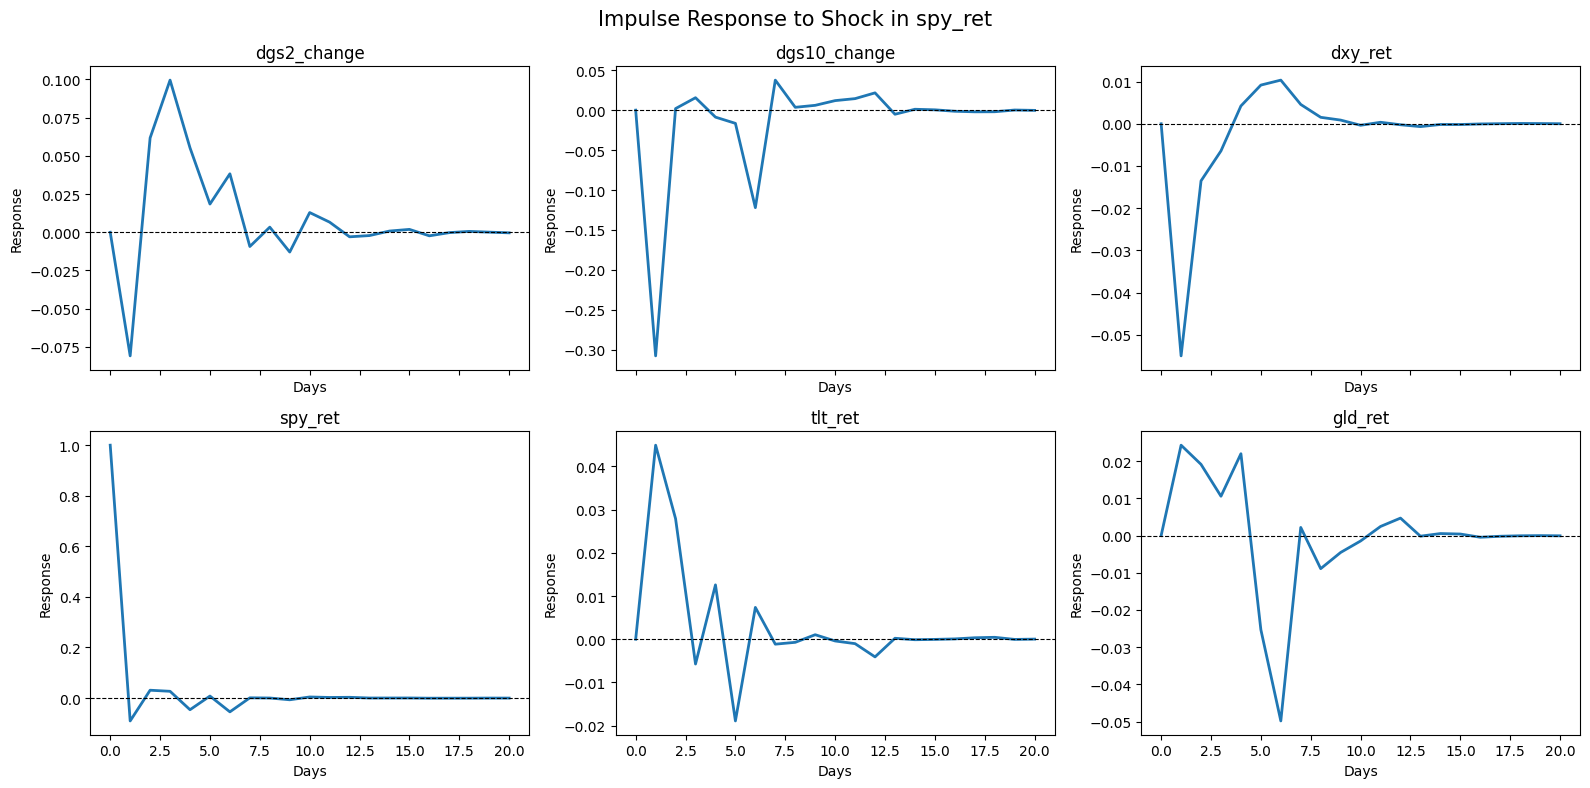

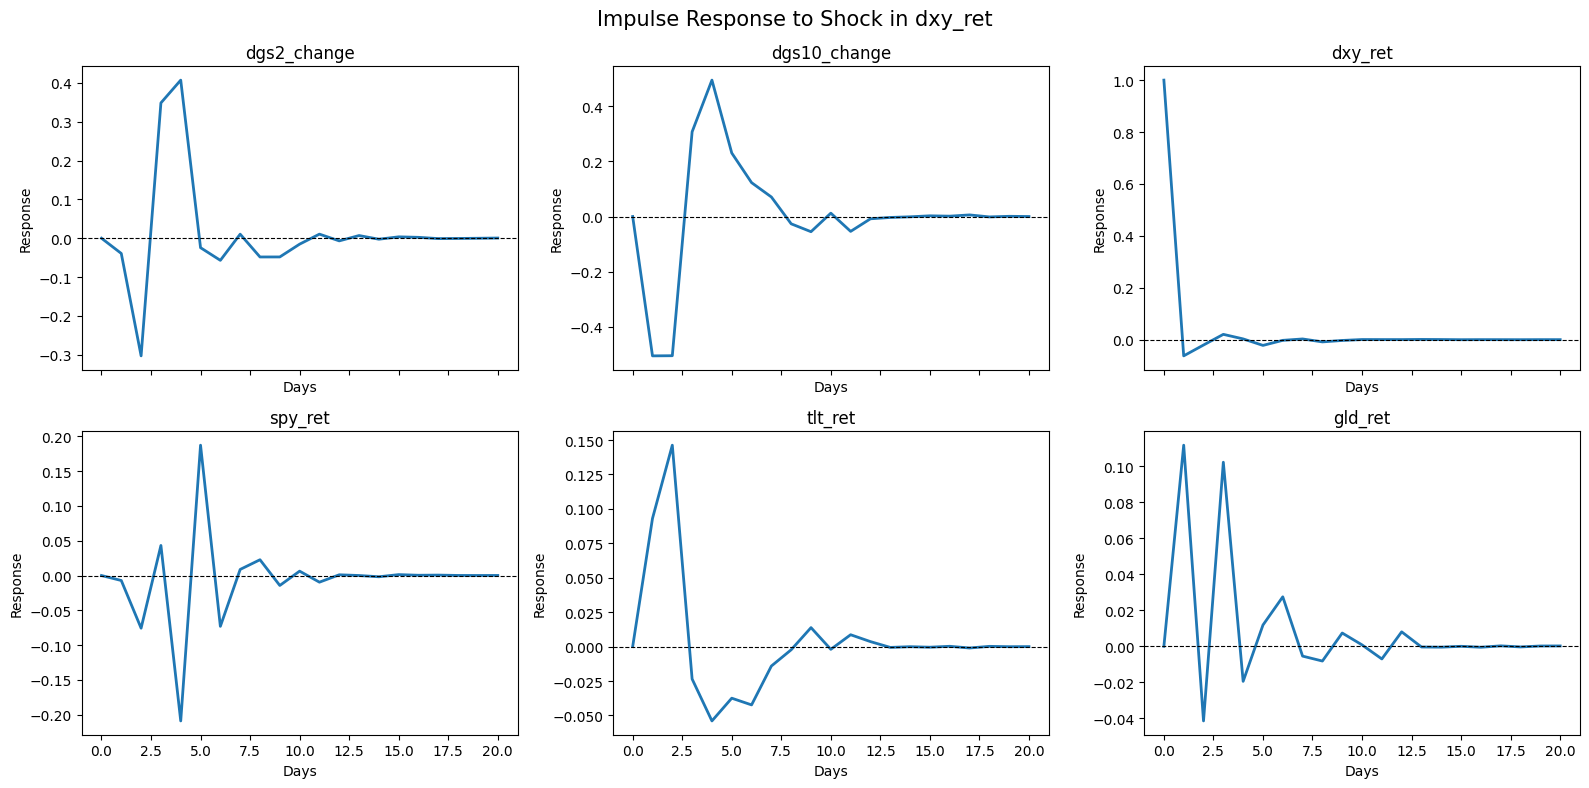

IRF SUMMARY
A 1-sd shock in 2Y yields leads to a -0.007945 change in SPY at day 3, with 95% CI [-0.000248, -0.000248]


In [16]:
# ============================
# Impulse Response Functions (IRFs)
# ============================

from statsmodels.tsa.api import VAR

# ============================
# Load Master Dataset
# ============================

master = pd.read_csv(
    DATA_DIR / "master_data.csv",
    parse_dates=["DATE"],
    index_col="DATE"
)

# ============================
# Variable Ordering (Cholesky)
# ============================

order = [
    "dgs2_change",
    "dgs10_change",
    "dxy_ret",
    "spy_ret",
    "tlt_ret",
    "gld_ret"
]

endog_data = (
    master[order]
    .dropna()
)

# ============================
# Fit VAR (same specification)
# ============================

model = VAR(endog_data)

lag_results = model.select_order(maxlags=10)

lag_order = lag_results.aic

if lag_order is None:
    lag_order = 2

lag_order = int(lag_order)

fitted = model.fit(lag_order)

# ============================
# Generate IRFs
# ============================

periods = 20

irf = fitted.irf(periods)

# 95% Monte-Carlo confidence bands
lower, upper = irf.errband_mc(
    orth=True,
    repl=1000,
    signif=0.05,
    seed=42
)

# ============================
# Plot Function
# ============================

def plot_irf_grid(impulse, filename):

    impulse_idx = order.index(impulse)

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(16, 8),
        sharex=True
    )

    axes = axes.flatten()

    horizon = np.arange(periods + 1)

    for i, response in enumerate(order):

        response_idx = order.index(response)

        ax = axes[i]

        ax.plot(
            horizon,
            irf.irfs[:, response_idx, impulse_idx],
            linewidth=2,
            label="IRF"
        )

        ax.fill_between(
            horizon,
            lower[:, response_idx, impulse_idx],
            upper[:, response_idx, impulse_idx],
            alpha=0.25
        )

        ax.axhline(
            0,
            color="black",
            linewidth=0.8,
            linestyle="--"
        )

        ax.set_title(response)
        ax.set_xlabel("Days")
        ax.set_ylabel("Response")

    fig.suptitle(
        f"Impulse Response to Shock in {impulse}",
        fontsize=15
    )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================
# Produce Figures
# ============================

plot_irf_grid(
    "dgs2_change",
    "irf_shock_2y.png"
)

plot_irf_grid(
    "spy_ret",
    "irf_shock_spy.png"
)

plot_irf_grid(
    "dxy_ret",
    "irf_shock_dxy.png"
)

# ============================
# Text Summary
# ============================

day = 3

impulse = "dgs2_change"
response = "spy_ret"

imp_idx = order.index(impulse)
resp_idx = order.index(response)

effect = irf.irfs[day, resp_idx, imp_idx]
ci_low = lower[day, resp_idx, imp_idx]
ci_high = upper[day, resp_idx, imp_idx]

print("=" * 60)
print("IRF SUMMARY")
print("=" * 60)
print(
    f"A 1-sd shock in 2Y yields leads to a "
    f"{effect:.6f} change in SPY at day {day}, "
    f"with 95% CI [{ci_low:.6f}, {ci_high:.6f}]"
)

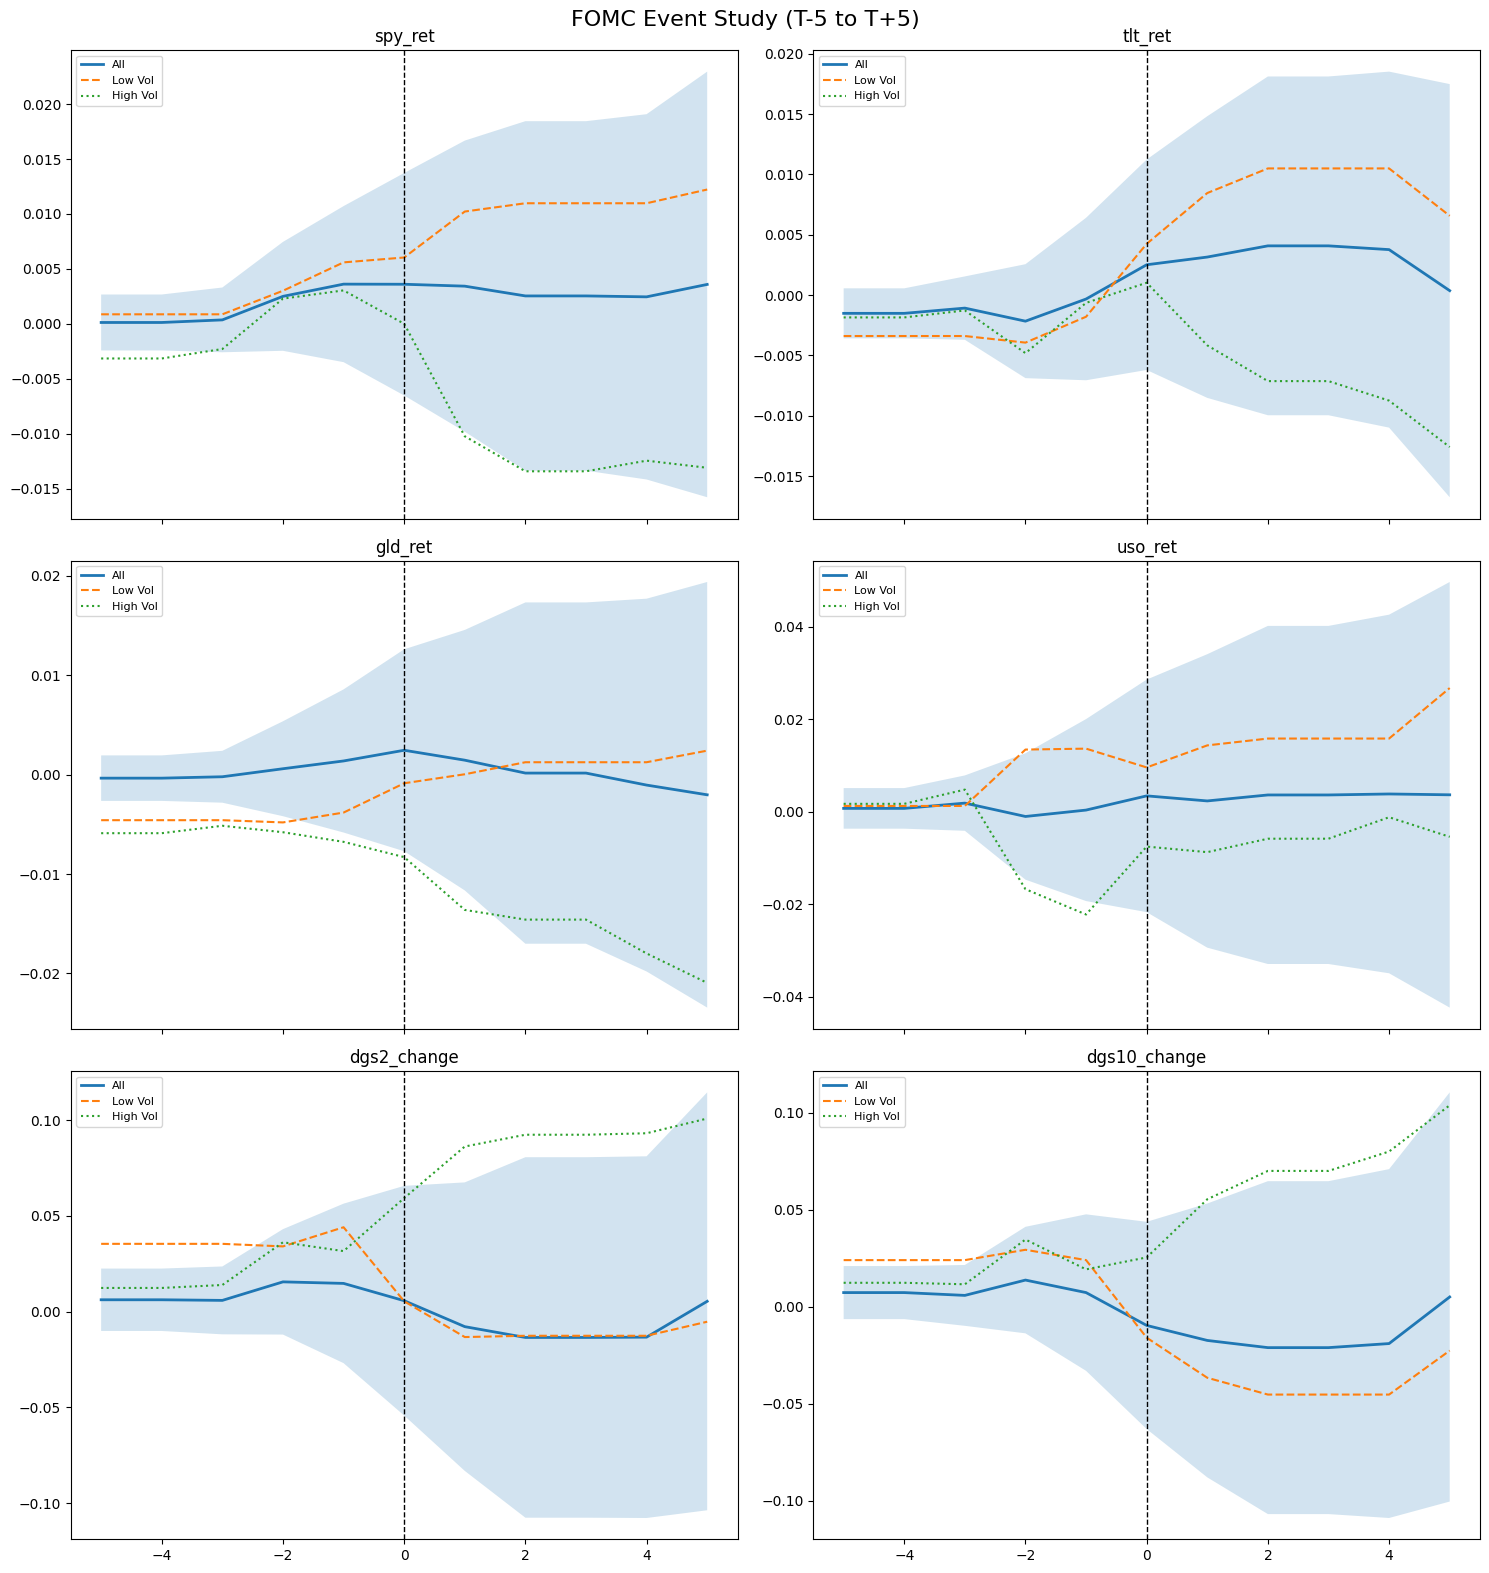

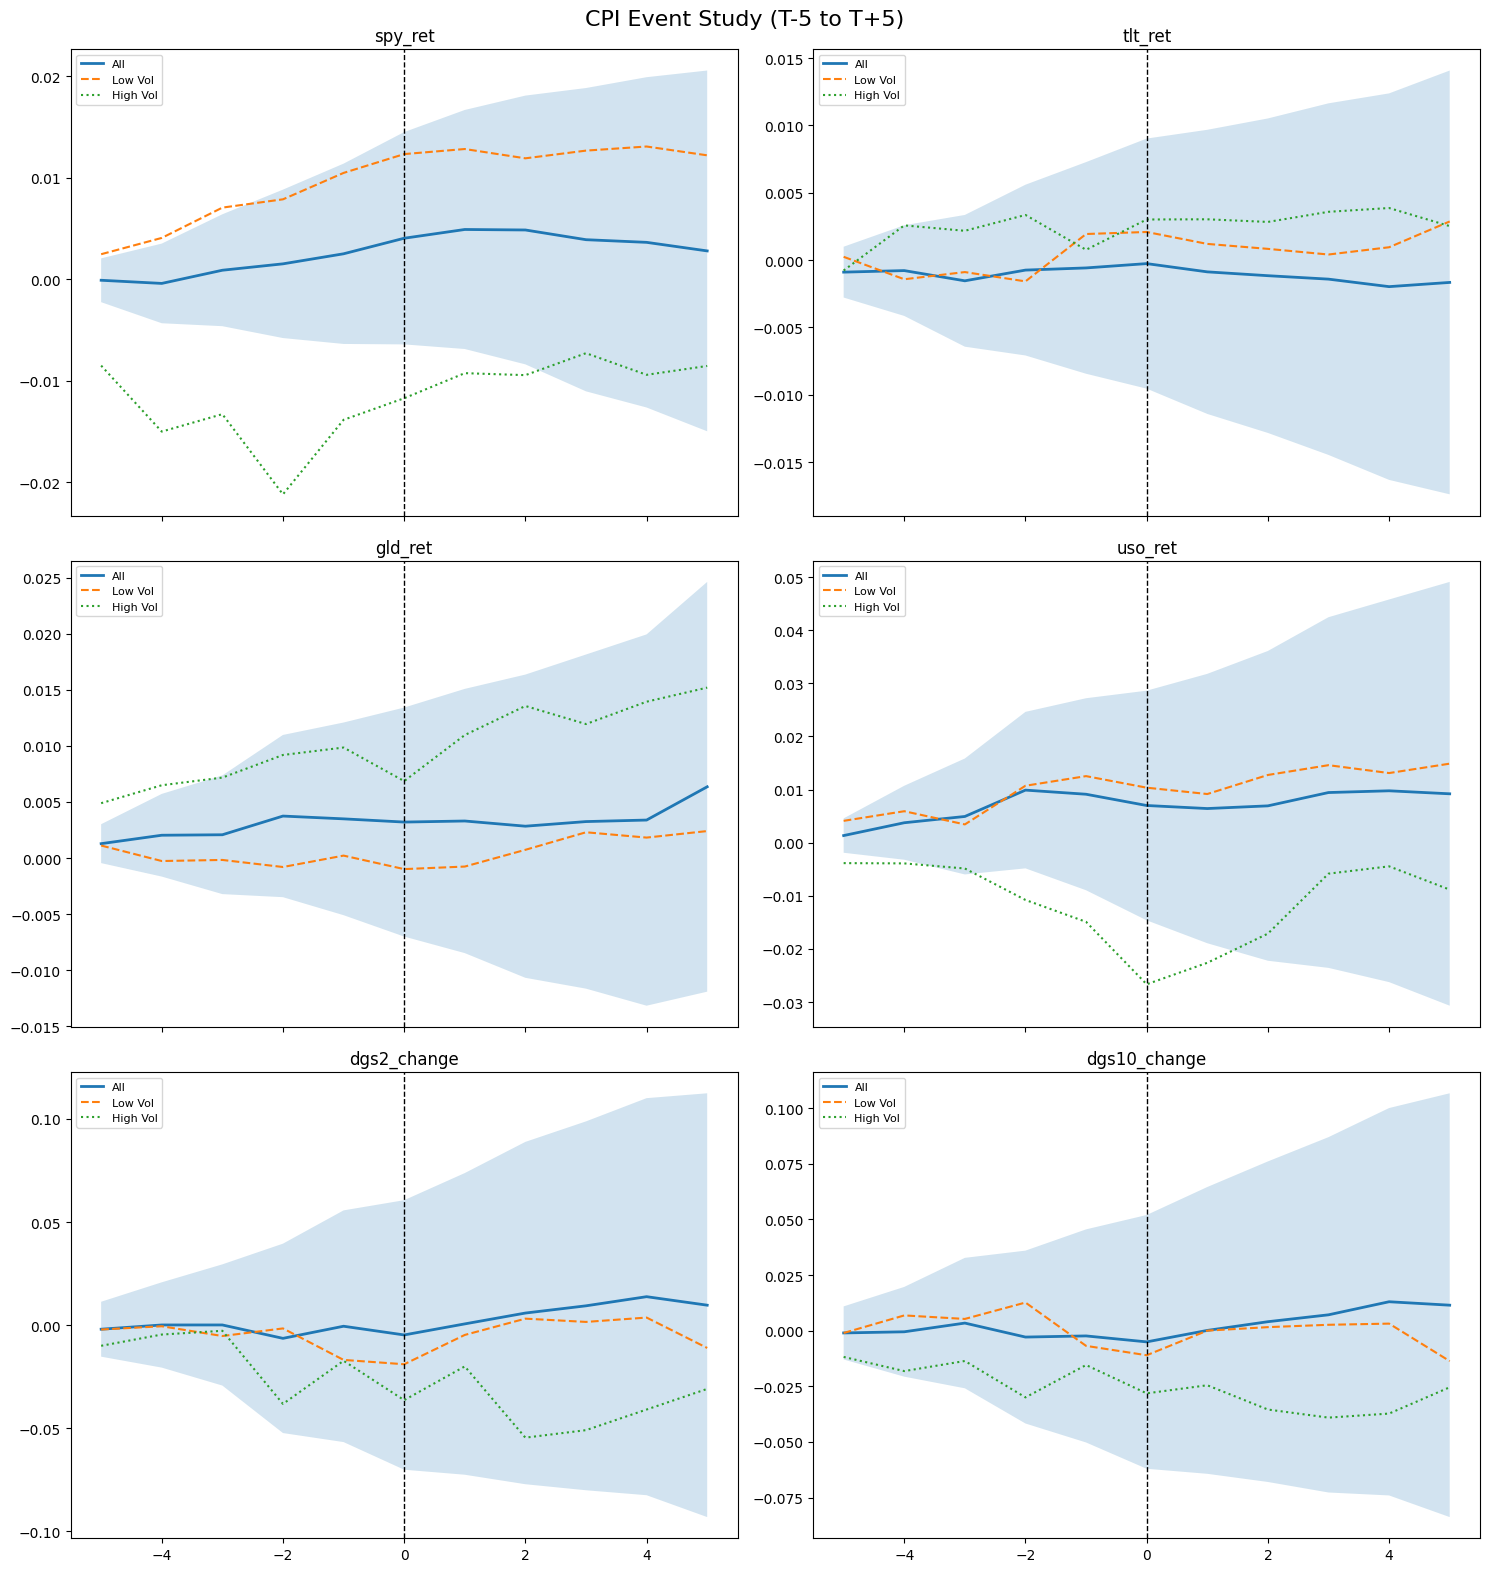

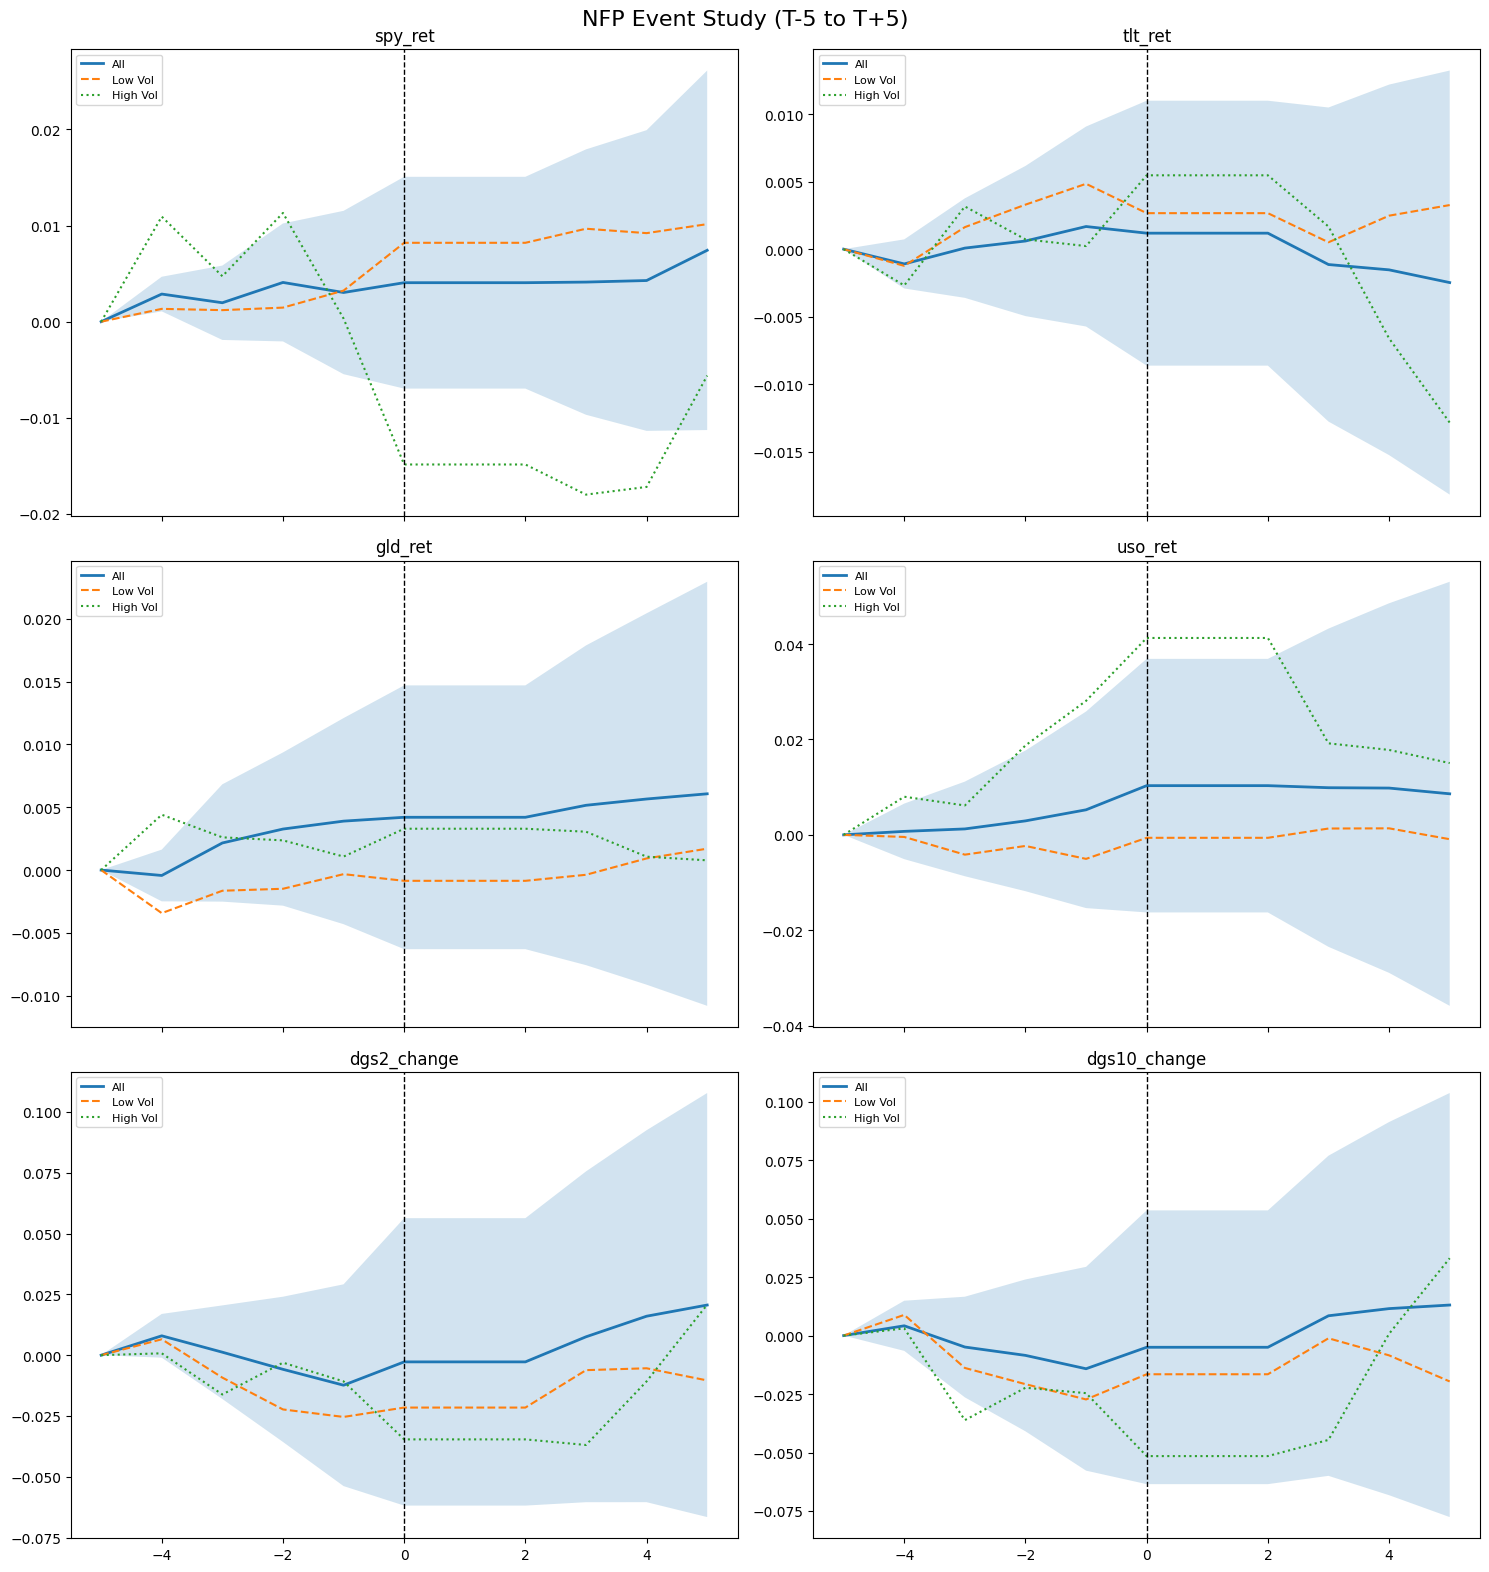

EVENT STUDY SUMMARY (T+1)
   Event         Asset       T+1  CI Lower  CI Upper  Significant
0   FOMC       spy_ret -0.000173 -0.003295  0.002949        False
1   FOMC       tlt_ret  0.000639 -0.002312  0.003591        False
2   FOMC       gld_ret -0.000998 -0.003945  0.001949        False
3   FOMC       uso_ret -0.001097 -0.007687  0.005493        False
4   FOMC   dgs2_change -0.013548 -0.028907  0.001810        False
5   FOMC  dgs10_change -0.007742 -0.024919  0.009435        False
6    CPI       spy_ret  0.000863 -0.000454  0.002180        False
7    CPI       tlt_ret -0.000613 -0.001877  0.000651        False
8    CPI       gld_ret  0.000096 -0.001475  0.001666        False
9    CPI       uso_ret -0.000573 -0.004312  0.003166        False
10   CPI   dgs2_change  0.005361 -0.002427  0.013149        False
11   CPI  dgs10_change  0.005155 -0.002264  0.012574        False
12   NFP       spy_ret  0.000000  0.000000  0.000000        False
13   NFP       tlt_ret  0.000000  0.000000  0.0000

In [17]:
# ============================
# Event Study Analysis
# ============================

master = pd.read_csv(
    DATA_DIR / "master_data.csv",
    parse_dates=["DATE"]
)

events = pd.read_csv(
    DATA_DIR / "events_data.csv",
    parse_dates=["DATE"]
)

master = master.sort_values("DATE").reset_index(drop=True)
master = master.set_index("DATE")

assets = [
    "spy_ret",
    "tlt_ret",
    "gld_ret",
    "uso_ret",
    "dgs2_change",
    "dgs10_change"
]

event_types = ["FOMC", "CPI", "NFP"]

window = range(-5, 6)

summary_rows = []

# ============================
# Event Loop
# ============================

for event in event_types:

    event_dates = events.loc[
        events["EVENT_TYPE"] == event,
        "DATE"
    ]

    fig, axes = plt.subplots(
        3,
        2,
        figsize=(15, 16),
        sharex=True
    )

    fig.suptitle(
        f"{event} Event Study (T-5 to T+5)",
        fontsize=16
    )

    for i, asset in enumerate(assets):

        ax = axes[i // 2, i % 2]

        paths = []

        low_paths = []

        high_paths = []

        for d in event_dates:

            if d not in master.index:
                continue

            loc = master.index.get_loc(d)

            if isinstance(loc, slice):
                continue

            if loc < 5 or loc + 5 >= len(master):
                continue

            segment = master.iloc[
                loc - 5: loc + 6
            ]

            vals = segment[asset].values

            if len(vals) != 11:
                continue

            paths.append(vals)

            regime = master.iloc[loc]["regime"]

            if regime == "low_vol":
                low_paths.append(vals)

            elif regime == "high_vol":
                high_paths.append(vals)

        if len(paths) == 0:
            ax.set_title(asset)
            continue

        paths = np.array(paths)

        mean = np.nanmean(paths, axis=0)

        se = np.nanstd(
            paths,
            axis=0,
            ddof=1
        ) / np.sqrt(paths.shape[0])

        ci = 1.96 * se

        cum = np.cumsum(mean)

        lower = np.cumsum(mean - ci)

        upper = np.cumsum(mean + ci)

        ax.plot(
            list(window),
            cum,
            label="All",
            linewidth=2
        )

        ax.fill_between(
            list(window),
            lower,
            upper,
            alpha=0.20
        )

        # -----------------------
        # Regime Overlay
        # -----------------------

        if len(low_paths) > 1:

            low_paths = np.array(low_paths)

            low_mean = np.cumsum(
                np.nanmean(low_paths, axis=0)
            )

            ax.plot(
                list(window),
                low_mean,
                linestyle="--",
                label="Low Vol"
            )

        if len(high_paths) > 1:

            high_paths = np.array(high_paths)

            high_mean = np.cumsum(
                np.nanmean(high_paths, axis=0)
            )

            ax.plot(
                list(window),
                high_mean,
                linestyle=":",
                label="High Vol"
            )

        ax.axvline(
            0,
            color="black",
            linestyle="--",
            linewidth=1
        )

        ax.set_title(asset)

        ax.legend(fontsize=8)

        # -----------------------
        # Summary Statistics
        # -----------------------

        t1 = mean[6]

        ci_low = t1 - ci[6]

        ci_high = t1 + ci[6]

        significant = (
            ci_low > 0
            or
            ci_high < 0
        )

        summary_rows.append({
            "Event": event,
            "Asset": asset,
            "T+1": t1,
            "CI Lower": ci_low,
            "CI Upper": ci_high,
            "Significant": significant
        })

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR /
        f"event_study_{event.lower()}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# ============================
# Summary Table
# ============================

summary = pd.DataFrame(summary_rows)

print("=" * 90)
print("EVENT STUDY SUMMARY (T+1)")
print("=" * 90)

print(
    summary[
        [
            "Event",
            "Asset",
            "T+1",
            "CI Lower",
            "CI Upper",
            "Significant"
        ]
    ]
)

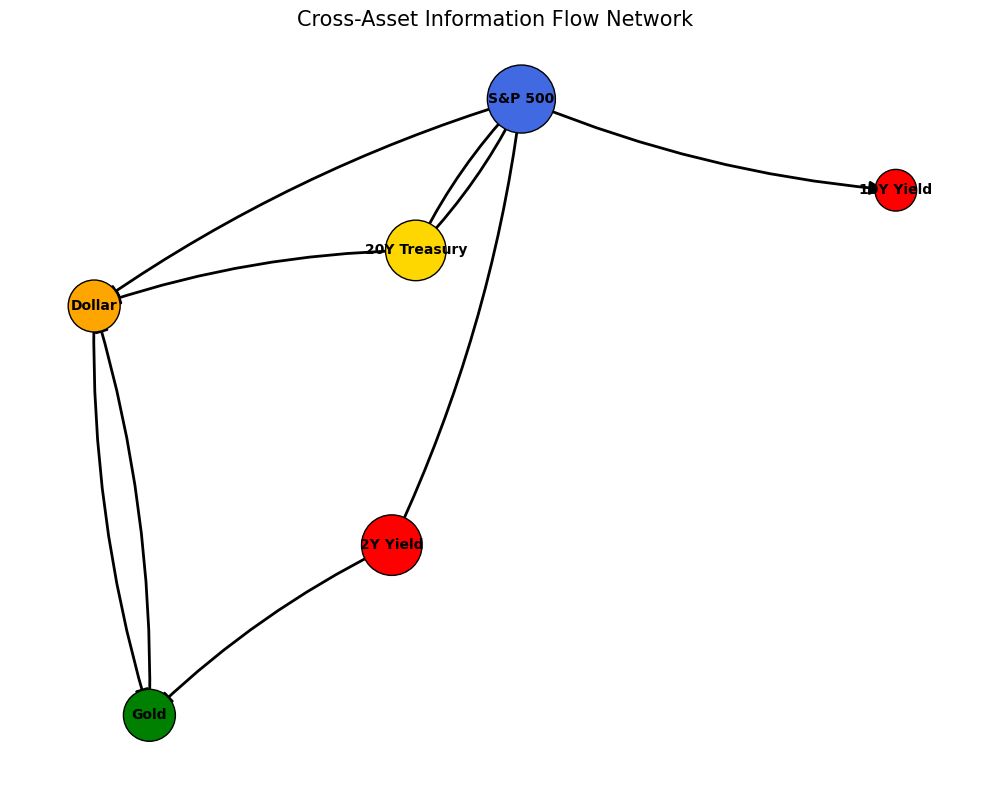

NETWORK SUMMARY
Information Leader   : S&P 500 (Out-degree = 3)
Information Follower : Dollar (In-degree  = 3)


In [18]:
# ============================
# Cross-Asset Information Flow Network
# ============================

import networkx as nx
from statsmodels.tsa.stattools import grangercausalitytests

# ============================
# Load Master Dataset
# ============================

master = pd.read_csv(
    DATA_DIR / "master_data.csv",
    parse_dates=["DATE"],
    index_col="DATE"
)

variables = [
    "spy_ret",
    "tlt_ret",
    "gld_ret",
    "dgs2_change",
    "dgs10_change",
    "dxy_ret"
]

data = master[variables].dropna()

# ============================
# Recalculate Binary Granger Matrix
# ============================

binary_matrix = pd.DataFrame(
    0,
    index=variables,
    columns=variables,
    dtype=int
)

for cause in variables:

    for effect in variables:

        if cause == effect:
            continue

        try:

            result = grangercausalitytests(
                data[[effect, cause]],
                maxlag=5,
                verbose=False
            )

            p = result[1][0]["ssr_ftest"][1]

            if p < 0.05:
                binary_matrix.loc[cause, effect] = 1

        except Exception:
            pass

# ============================
# Labels
# ============================

labels = {
    "spy_ret": "S&P 500",
    "tlt_ret": "20Y Treasury",
    "gld_ret": "Gold",
    "dgs2_change": "2Y Yield",
    "dgs10_change": "10Y Yield",
    "dxy_ret": "Dollar"
}

colors = {
    "S&P 500": "royalblue",
    "20Y Treasury": "gold",
    "Gold": "green",
    "2Y Yield": "red",
    "10Y Yield": "red",
    "Dollar": "orange"
}

# ============================
# Build Graph
# ============================

G = nx.DiGraph()

for node in labels.values():
    G.add_node(node)

for cause in variables:

    for effect in variables:

        if binary_matrix.loc[cause, effect] == 1:

            G.add_edge(
                labels[cause],
                labels[effect]
            )

# ============================
# Node Properties
# ============================

out_deg = dict(G.out_degree())
in_deg = dict(G.in_degree())

node_sizes = [
    900 + 500 * out_deg[node]
    for node in G.nodes()
]

node_colors = [
    colors[node]
    for node in G.nodes()
]

# ============================
# Plot
# ============================

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(
    G,
    seed=42,
    k=1.2
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors="black",
    linewidths=1
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold"
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=20,
    arrowstyle="-|>",
    width=2,
    connectionstyle="arc3,rad=0.08"
)

plt.title(
    "Cross-Asset Information Flow Network",
    fontsize=15
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "granger_network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================
# Information Leader/Follower
# ============================

leader = max(
    out_deg,
    key=out_deg.get
)

follower = max(
    in_deg,
    key=in_deg.get
)

print("=" * 60)
print("NETWORK SUMMARY")
print("=" * 60)

print(f"Information Leader   : {leader} (Out-degree = {out_deg[leader]})")
print(f"Information Follower : {follower} (In-degree  = {in_deg[follower]})")

DCC unavailable. Using exponentially weighted Kendall correlation.
Using exponentially weighted rolling Pearson correlation.


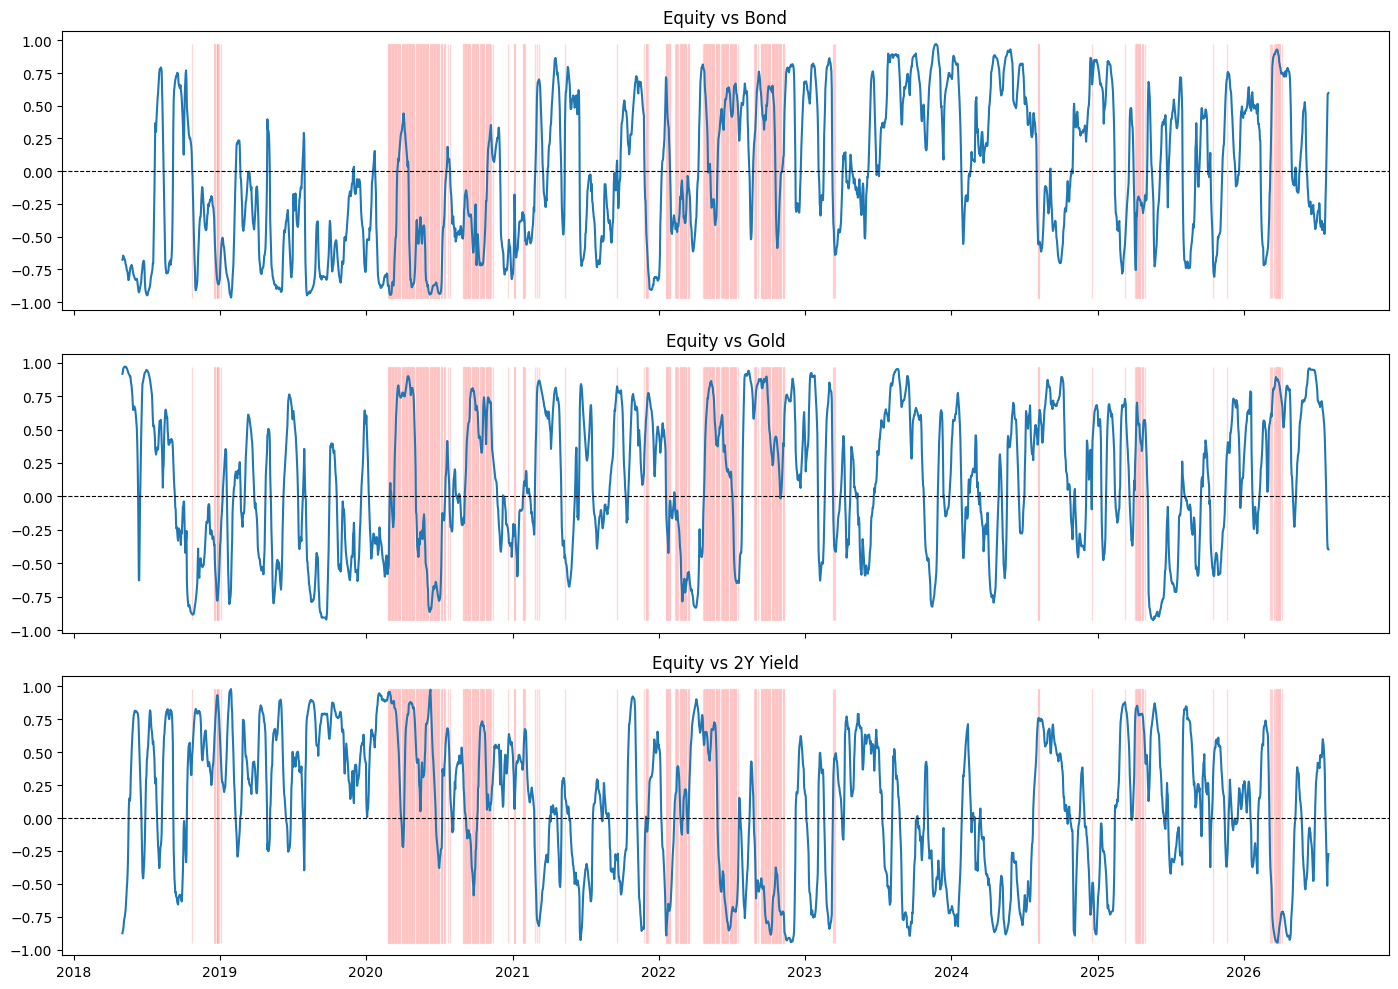

Average Dynamic Correlations
          SPY-TLT  SPY-GLD  SPY-2Y
Low Vol     0.067    0.100   0.038
High Vol   -0.148    0.211   0.096


In [22]:
# ============================
# Dynamic Correlation Analysis
# ============================

import warnings
warnings.filterwarnings("ignore")

from arch import arch_model

master = pd.read_csv(
    DATA_DIR / "master_data.csv",
    parse_dates=["DATE"],
    index_col="DATE"
)

master = (
    master
    .sort_index()
    .loc[~master.index.duplicated(keep="first")]
)

assets = [
    "spy_ret",
    "tlt_ret",
    "gld_ret",
    "dgs2_change"
]

data = master[assets].dropna()

# ==========================================================
# Attempt DCC (only if supported by installed ARCH version)
# ==========================================================

use_fallback = False

try:

    from arch.covariance import DCC

    std_resids = []

    for col in assets:

        am = arch_model(
            data[col] * 100,
            mean="Zero",
            vol="GARCH",
            p=1,
            q=1,
            rescale=False
        )

        res = am.fit(disp="off")

        std_resids.append(res.std_resid)

    std_resids = pd.concat(std_resids, axis=1)
    std_resids.columns = assets

    dcc = DCC(std_resids)

    dcc_res = dcc.fit(disp="off")

    cov = dcc_res.dynamic_covariance

    corr_spy_tlt = []
    corr_spy_gld = []
    corr_spy_dgs2 = []

    for i in range(len(std_resids)):

        C = cov[i]

        D = np.sqrt(np.diag(C))

        R = C / np.outer(D, D)

        corr_spy_tlt.append(R[0,1])
        corr_spy_gld.append(R[0,2])
        corr_spy_dgs2.append(R[0,3])

    corr = pd.DataFrame({
        "spy_tlt": corr_spy_tlt,
        "spy_gld": corr_spy_gld,
        "spy_dgs2": corr_spy_dgs2
    }, index=data.index)

    print("Using DCC-GARCH")

except Exception:

    print("DCC unavailable. Using exponentially weighted Kendall correlation.")

    use_fallback = True

# ==========================================================
# Fallback
# ==========================================================

if use_fallback:

    print("Using exponentially weighted rolling Pearson correlation.")

    ew = data.ewm(
        halflife=30,
        adjust=False
    ).mean()

    corr = pd.DataFrame(index=data.index)

    corr["spy_tlt"] = (
        ew["spy_ret"]
        .rolling(window=30)
        .corr(ew["tlt_ret"])
    )

    corr["spy_gld"] = (
        ew["spy_ret"]
        .rolling(window=30)
        .corr(ew["gld_ret"])
    )

    corr["spy_dgs2"] = (
        ew["spy_ret"]
        .rolling(window=30)
        .corr(ew["dgs2_change"])
    )
# ==========================================================
# Plot
# ==========================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14,10),
    sharex=True
)

pairs = [
    ("spy_tlt","Equity vs Bond"),
    ("spy_gld","Equity vs Gold"),
    ("spy_dgs2","Equity vs 2Y Yield")
]

for ax,(col,title) in zip(axes,pairs):

    ax.plot(
        corr.index,
        corr[col],
        linewidth=1.5
    )

    high = (
    master["VIX"]
    .reindex(corr.index)
    .gt(25)
    .fillna(False)
    .to_numpy()
)

    ax.fill_between(
        corr.index,
        corr[col].min(),
        corr[col].max(),
        where=high,
        color="red",
        alpha=0.15
    )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.8
    )

    ax.set_title(title)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "dcc_correlation_dynamics.png",
    dpi=300
)

plt.show()

# ==========================================================
# Summary
# ==========================================================

summary = pd.DataFrame(index=["Low Vol","High Vol"])

mask_low = master.loc[corr.index,"regime"]=="low_vol"
mask_high = master.loc[corr.index,"regime"]=="high_vol"

summary["SPY-TLT"] = [
    corr.loc[mask_low,"spy_tlt"].mean(),
    corr.loc[mask_high,"spy_tlt"].mean()
]

summary["SPY-GLD"] = [
    corr.loc[mask_low,"spy_gld"].mean(),
    corr.loc[mask_high,"spy_gld"].mean()
]

summary["SPY-2Y"] = [
    corr.loc[mask_low,"spy_dgs2"].mean(),
    corr.loc[mask_high,"spy_dgs2"].mean()
]

print("="*65)
print("Average Dynamic Correlations")
print("="*65)
print(summary.round(3))

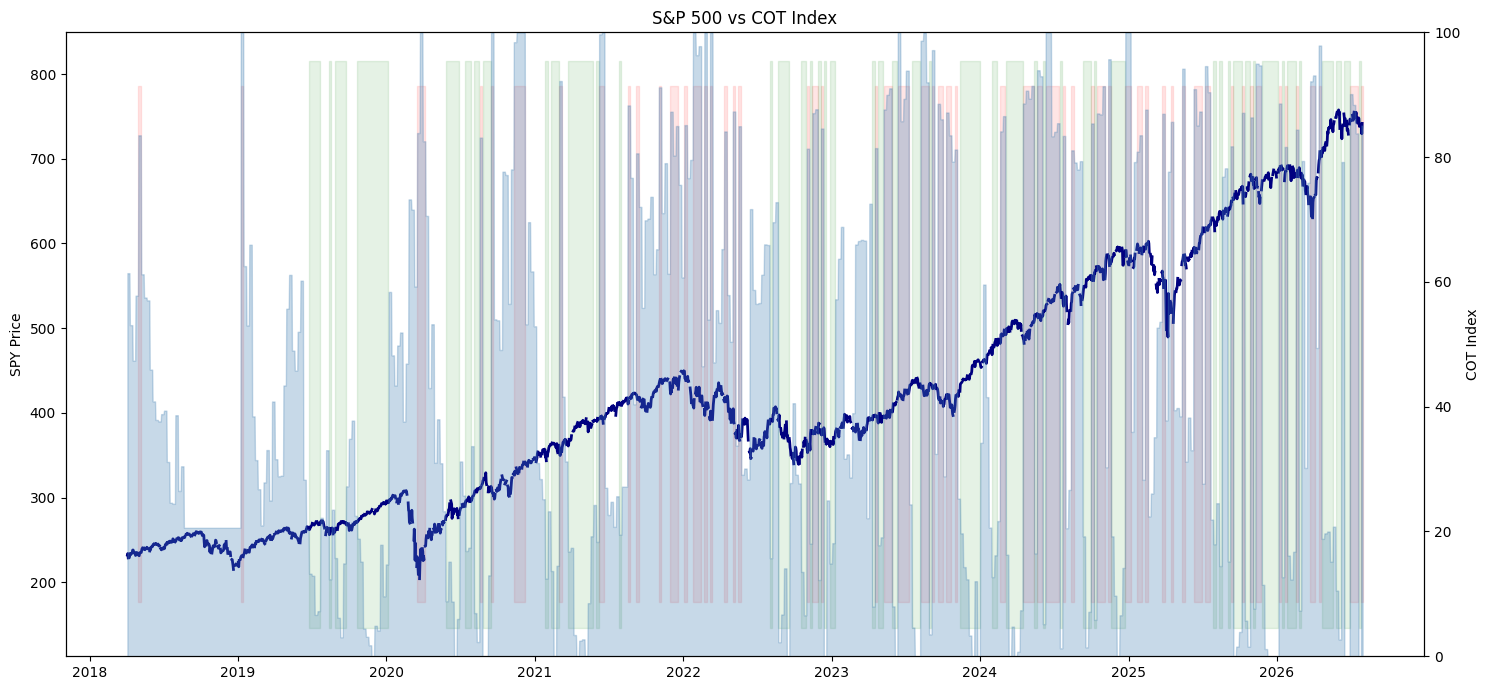

COT INDEX EXTREME EVENTS
      DATE   signal  COT_Index  SPY_20D_Return
2018-05-01 Above 80     83.495           0.032
2019-01-08 Above 80    100.000           0.027
2019-06-25 Below 20     13.233           0.034
2019-08-13 Below 20     12.338             NaN
2019-08-27 Below 20     15.740           0.046
2019-10-22 Below 20     18.839           0.031
2020-03-17 Above 80     83.861           0.054
2020-05-26 Below 20      8.814           0.027
2020-07-14 Below 20     16.866           0.031
2020-08-04 Below 20      6.925           0.039
2020-08-18 Above 80     83.128             NaN
2020-08-25 Below 20      0.000          -0.016
2020-09-15 Above 80    100.000           0.003
2020-11-10 Above 80     98.422           0.023
2021-01-26 Below 20     12.439             NaN
2021-02-09 Below 20     13.665          -0.002
2021-03-02 Above 80     92.202           0.019
2021-03-23 Below 20     16.788           0.057
2021-06-01 Below 20     18.323           0.006
2021-06-08 Above 80     99.680     

In [27]:
# ============================
# COT Positioning vs S&P 500
# ============================

master = pd.read_csv(
    DATA_DIR / "master_data.csv",
    parse_dates=["DATE"]
)

cot = pd.read_csv(
    DATA_DIR / "cot_data.csv",
    parse_dates=["Report_Date_as_YYYY_MM_DD"]
)

# ==========================================================
# Select E-Mini S&P 500
# ==========================================================

sp_cot = (
    cot[
        cot["Market_and_Exchange_Names"]
        .str.contains("E-MINI S&P 500", case=False, na=False)
    ]
    .copy()
)


# ==========================================================
# 52-Week COT Index
# ==========================================================

window = 52

rolling_min = (
    sp_cot["noncomm_net"]
    .rolling(window, min_periods=20)
    .min()
)

rolling_max = (
    sp_cot["noncomm_net"]
    .rolling(window, min_periods=20)
    .max()
)

sp_cot["COT_Index"] = (
    (
        sp_cot["noncomm_net"] - rolling_min
    )
    /
    (
        rolling_max - rolling_min
    )
) * 100

sp_cot["COT_Index"] = (
    sp_cot["COT_Index"]
    .clip(0, 100)
)


# ==========================================================
# Daily Alignment
# ==========================================================

cot_daily = (
    sp_cot[
        [
            "Report_Date_as_YYYY_MM_DD",
            "COT_Index"
        ]
    ]
    .rename(
        columns={
            "Report_Date_as_YYYY_MM_DD":"DATE"
        }
    )
    .sort_values("DATE")
)

master = master.sort_values("DATE")

master = pd.merge_asof(
    master,
    cot_daily,
    on="DATE",
    direction="backward"
)

master["COT_Index"] = master["COT_Index"].ffill()

# ==========================================================
# Plot
# ==========================================================

fig, ax1 = plt.subplots(
    figsize=(15,7)
)

ax2 = ax1.twinx()

ax1.plot(
    master["DATE"],
    master["SPY"],
    color="navy",
    linewidth=2,
    label="SPY"
)

ax2.fill_between(
    master["DATE"],
    master["COT_Index"],
    color="steelblue",
    alpha=0.30,
    label="COT Index"
)

bull = master["COT_Index"] > 80
bear = master["COT_Index"] < 20

ax1.fill_between(
    master["DATE"],
    ax1.get_ylim()[0],
    ax1.get_ylim()[1],
    where=bull,
    color="red",
    alpha=0.10
)

ax1.fill_between(
    master["DATE"],
    ax1.get_ylim()[0],
    ax1.get_ylim()[1],
    where=bear,
    color="green",
    alpha=0.10
)

ax1.set_ylabel("SPY Price")

ax2.set_ylabel("COT Index")

ax2.set_ylim(0,100)

plt.title("S&P 500 vs COT Index")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "cot_sp500_extremes.png",
    dpi=300
)

plt.show()

# ==========================================================
# Threshold Crossings
# ==========================================================

master["signal"] = np.select(
    [
        (master["COT_Index"] > 80) &
        (master["COT_Index"].shift(1) <= 80),

        (master["COT_Index"] < 20) &
        (master["COT_Index"].shift(1) >= 20)
    ],
    [
        "Above 80",
        "Below 20"
    ],
    default=""
)

events = master[
    master["signal"] != ""
].copy()

events["SPY_20D_Return"] = (
    master["SPY"]
    .shift(-20)
    .loc[events.index]
    .values
    /
    master.loc[events.index,"SPY"].values
    -
    1
)

print("="*80)
print("COT INDEX EXTREME EVENTS")
print("="*80)

print(
    events[
        [
            "DATE",
            "signal",
            "COT_Index",
            "SPY_20D_Return"
        ]
    ]
    .round(3)
    .to_string(index=False)
)

In [28]:
# ============================
# CAMTA TRANSMISSION REPORT
# ============================

import os
import numpy as np
import pandas as pd
import networkx as nx
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.api import VAR

# ==========================================================
# Load Data
# ==========================================================

master = pd.read_csv(
    DATA_DIR / "master_data.csv",
    parse_dates=["DATE"]
)

master = (
    master
    .sort_values("DATE")
    .drop_duplicates(subset="DATE")
    .reset_index(drop=True)
)

# Optional datasets
cot = None
if os.path.exists(DATA_DIR / "cot_data.csv"):
    cot = pd.read_csv(
        DATA_DIR / "cot_data.csv",
        parse_dates=["Report_Date_as_YYYY_MM_DD"]
    )

events = None
if os.path.exists(DATA_DIR / "events_data.csv"):
    events = pd.read_csv(
        DATA_DIR / "events_data.csv",
        parse_dates=["DATE"]
    )

# ==========================================================
# SECTION 1
# ==========================================================

assets = [
    "SPY",
    "TLT",
    "GLD",
    "USO",
    "DXY",
    "DGS2",
    "DGS10"
]

overview = []

overview.append("SECTION 1: DATA OVERVIEW")
overview.append("-"*60)
overview.append(f"Observations : {len(master):,}")
overview.append(
    f"Date Range   : {master.DATE.min().date()} to {master.DATE.max().date()}"
)
overview.append(
    f"Assets       : {', '.join(assets)}"
)
overview.append("")
overview.append("Missing Data (%)")

for col in assets:
    if col in master.columns:
        pct = 100*master[col].isna().mean()
        overview.append(f"{col:<10} {pct:6.2f}%")

# ==========================================================
# SECTION 2
# ==========================================================

regime = []

regime.append("")
regime.append("SECTION 2: REGIME SUMMARY")
regime.append("-"*60)

counts = master["regime"].value_counts()

for k,v in counts.items():
    regime.append(f"{k:<12} {v}")

regime.append("")

for r in master["regime"].dropna().unique():

    df = master[master["regime"]==r]

    regime.append(
        f"{r:<12} "
        f"SPY={df['spy_ret'].mean():.5f}  "
        f"TLT={df['tlt_ret'].mean():.5f}"
    )

# ==========================================================
# SECTION 3
# ==========================================================

vars_ = [
    "spy_ret",
    "tlt_ret",
    "gld_ret",
    "dgs2_change",
    "dgs10_change",
    "dxy_ret"
]

labels = {
    "spy_ret":"S&P 500",
    "tlt_ret":"20Y Treasury",
    "gld_ret":"Gold",
    "dgs2_change":"2Y Yield",
    "dgs10_change":"10Y Yield",
    "dxy_ret":"Dollar"
}

data = master[vars_].dropna()

G = nx.DiGraph()

for v in vars_:
    G.add_node(v)

pvals = {}

for c in vars_:

    for e in vars_:

        if c==e:
            continue

        try:

            p = grangercausalitytests(
                data[[e,c]],
                maxlag=5,
                verbose=False
            )[1][0]["ssr_ftest"][1]

            pvals[(c,e)] = p

            if p<0.05:
                G.add_edge(c,e)

        except:
            pass

leaders = sorted(
    G.out_degree,
    key=lambda x:x[1],
    reverse=True
)

followers = sorted(
    G.in_degree,
    key=lambda x:x[1],
    reverse=True
)

lead = []

lead.append("")
lead.append("SECTION 3: LEAD-LAG RANKINGS")
lead.append("-"*60)

lead.append("Top Information Leaders")

for n,d in leaders[:3]:
    lead.append(f"{labels[n]} ({d})")

lead.append("")

lead.append("Top Information Followers")

for n,d in followers[:3]:
    lead.append(f"{labels[n]} ({d})")

lead.append("")
lead.append("Leader -> Follower p-values")

for n,_ in leaders[:3]:

    if G.out_degree(n)==0:
        continue

    for m in G.successors(n):

        lead.append(
            f"{labels[n]} -> {labels[m]} : "
            f"{pvals[(n,m)]:.5f}"
        )

# ==========================================================
# SECTION 4
# ==========================================================

order = [
    "dgs2_change",
    "dgs10_change",
    "dxy_ret",
    "spy_ret",
    "tlt_ret",
    "gld_ret"
]

endog = master[order].dropna()

model = VAR(endog)

lag = model.select_order(10).aic

if lag is None:
    lag=2

lag=int(lag)

fit=model.fit(lag)

irf=fit.irf(20)

shock=[]

shock.append("")
shock.append("SECTION 4: SHOCK TRANSMISSION TIMELINE")
shock.append("-"*60)

paths=[]

for i,imp in enumerate(order):

    for j,res in enumerate(order):

        if i==j:
            continue

        arr=irf.irfs[:,j,i]

        peak=np.argmax(np.abs(arr))

        mag=arr[peak]

        paths.append(
            (
                abs(mag),
                imp,
                res,
                peak,
                mag
            )
        )

paths=sorted(paths,reverse=True)

for _,imp,res,pk,mg in paths[:5]:

    shock.append(
        f"Shock in {imp} "
        f"causes {res} "
        f"to peak on day {pk} "
        f"(magnitude {mg:.5f})"
    )

# ==========================================================
# SECTION 5
# ==========================================================

event=[]

event.append("")
event.append("SECTION 5: EVENT STUDY INSIGHTS")
event.append("-"*60)

if events is not None:

    master_idx=master.set_index("DATE")

    for e in ["FOMC","CPI","NFP"]:

        dts=events[
            events.EVENT_TYPE==e
        ]["DATE"]

        t0=[]
        t5=[]

        for d in dts:

            if d not in master_idx.index:
                continue

            loc=master_idx.index.get_loc(d)

            if isinstance(loc,slice):
                continue

            if loc+5>=len(master_idx):
                continue

            t0.append(master_idx.iloc[loc]["spy_ret"])

            t5.append(
                master_idx.iloc[
                    loc+1:loc+6
                ]["spy_ret"].mean()
            )

        event.append(
            f"{e:<5} "
            f"T0={np.nanmean(t0):.5f} "
            f"T1-5={np.nanmean(t5):.5f}"
        )

high=master[
    master.regime=="high_vol"
]["spy_ret"].abs().mean()

low=master[
    master.regime=="low_vol"
]["spy_ret"].abs().mean()

event.append("")

if high>low:
    event.append(
        "High-vol regime amplifies event reactions."
    )
else:
    event.append(
        "High-vol regime dampens event reactions."
    )

# ==========================================================
# SECTION 6
# ==========================================================

cot_sec=[]

cot_sec.append("")
cot_sec.append("SECTION 6: COT POSITIONING SIGNAL")
cot_sec.append("-"*60)

if cot is not None:

    if "COT_Index" in cot.columns:

        latest=cot["COT_Index"].iloc[-1]

        cot_sec.append(
            f"Current COT Index : {latest:.2f}"
        )

    elif "noncomm_net" in cot.columns:

        x=cot["noncomm_net"]

        idx=100*(
            (x.iloc[-1]-x.min())
            /
            (x.max()-x.min())
        )

        cot_sec.append(
            f"Approx Current COT Index : {idx:.2f}"
        )

    cot_sec.append(
        "Contrarian signals are generally strongest "
        "when positioning exceeds historical extremes."
    )

# ==========================================================
# SECTION 7
# ==========================================================

desk=[]

desk.append("")
desk.append("SECTION 7: TRADING DESK IMPLICATIONS")
desk.append("-"*60)

desk.append(
"• Monitor Granger leaders for early cross-asset signals."
)

desk.append(
"• Rising VIX weakens equity diversification benefits."
)

desk.append(
"• Yield shocks propagate rapidly into equities."
)

desk.append(
"• Extreme COT positioning can identify crowded trades."
)

desk.append(
"• Combine macro events with volatility regime filters before taking directional risk."
)

# ==========================================================
# Write Report
# ==========================================================

report = (
    overview
    + regime
    + lead
    + shock
    + event
    + cot_sec
    + desk
)

report_path = OUTPUT_DIR / "TRANSMISSION_REPORT.txt"

with open(report_path,"w",encoding="utf-8") as f:

    f.write("\n".join(report))

# ==========================================================
# Summary Metrics
# ==========================================================

summary=[]

for a in assets:

    if a not in master.columns:
        continue

    summary.append({

        "Asset":a,

        "Mean":
        master[a].mean(),

        "Std":
        master[a].std(),

        "Min":
        master[a].min(),

        "Max":
        master[a].max(),

        "Missing_%":
        100*master[a].isna().mean()

    })

summary=pd.DataFrame(summary)

summary.to_csv(
    OUTPUT_DIR/"summary_metrics.csv",
    index=False
)

print("="*70)
print("TRANSMISSION REPORT CREATED")
print("="*70)
print(report_path)
print()
print(summary)

TRANSMISSION REPORT CREATED
/content/outputs/TRANSMISSION_REPORT.txt

   Asset        Mean         Std         Min         Max  Missing_%
0    SPY  418.261611  142.437418  204.418259  757.618225  31.206840
1    TLT  100.876341   17.964799   73.702705  142.699539  31.206840
2    GLD  202.309785   84.400920  111.099998  495.899994  31.206840
3    USO   74.220406   25.125491   17.040001  152.960007  31.206840
4    DXY   99.246075    4.999568   89.430000  114.110001  31.141072
5   DGS2    2.712861    1.636396    0.090000    5.190000   0.000000
6  DGS10    2.957280    1.289804    0.520000    4.980000   0.000000
